In [445]:


# IMPORTY
# =====================================
import pandas as pd
import numpy as np
from scipy import stats
import seaborn as sns
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.inspection import PartialDependenceDisplay
from scipy.stats import ks_2samp
from sklearn.metrics import roc_auc_score, average_precision_score, log_loss, brier_score_loss, roc_curve, precision_recall_curve, confusion_matrix, ConfusionMatrixDisplay
import optuna
from optuna import visualization as vis
from sklearn.linear_model import LogisticRegression
from IPython.display import display
from statsmodels.stats.outliers_influence import variance_inflation_factor
from statsmodels.tools.tools import add_constant
import statsmodels.api as sm
from IPython.display import display
from sklearn.calibration import calibration_curve, CalibratedClassifierCV
from scipy.special import expit, logit
from scipy.optimize import newton
from sklearn.base import BaseEstimator, ClassifierMixin
import copy

import warnings

# Ignore all warnings
warnings.filterwarnings("ignore")

In [446]:
# PARAMETRY
# =====================================
DATA_PATH = "zbiór_8.csv"
RANDOM_SEED = 3
CORR_THRESHOLD = 0.8
N_BINS = 8
EPS = 1e-6
IV_THRESHOLD = 0.1



In [462]:
# WCZYTANIE + SPLIT
# =====================================
df = pd.read_csv(DATA_PATH)

df_train, df_tmp = train_test_split(df, train_size=0.7, stratify=df["default"], random_state=RANDOM_SEED)
df_val, df_test = train_test_split(df_tmp, test_size=0.5, stratify=df_tmp["default"], random_state=RANDOM_SEED)

X_train, y_train = df_train.drop(columns="default"), df_train["default"]
X_val, y_val = df_val.drop(columns="default"), df_val["default"]
X_test, y_test = df_test.drop(columns="default"), df_test["default"]

In [463]:
# -------------------------------------
# WRAPPERY DO ZACHOWANIA NAZW KOLUMN
# -------------------------------------
class ColumnNamePreservingPipeline(Pipeline):
    def transform(self, X):
        X_transformed = super().transform(X)
        if isinstance(X_transformed, np.ndarray):
            if hasattr(self.steps[-1][1], "get_feature_names_out"):
                cols = self.steps[-1][1].get_feature_names_out(X.columns)
            else:
                cols = X.columns
            X_transformed = pd.DataFrame(X_transformed, columns=cols, index=X.index)
        return X_transformed

    def fit_transform(self, X, y=None, **fit_params):
        Xt = super().fit_transform(X, y, **fit_params)
        if isinstance(Xt, np.ndarray):
            if hasattr(self.steps[-1][1], "get_feature_names_out"):
                cols = self.steps[-1][1].get_feature_names_out(X.columns)
            else:
                cols = X.columns
            Xt = pd.DataFrame(Xt, columns=cols, index=X.index)
        return Xt



class ColumnNamePreservingCT(ColumnTransformer):
    def transform(self, X):
        X_transformed = super().transform(X)
        cols = []
        for name, trans, cols_in in self.transformers_:
            if trans == 'drop':
                continue
            if hasattr(trans, 'get_feature_names_out'):
                cols.extend(trans.get_feature_names_out(cols_in))
            else:
                cols.extend(cols_in)
        return pd.DataFrame(X_transformed, columns=cols, index=X.index)


In [464]:
# =====================================
# TRANSFORMATORY
# =====================================

class UnimportantDropper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        zero_percentage = (X[:] == 0).sum() / len(X)

        cols_many_zeros = zero_percentage[zero_percentage > 0.5].index.tolist()

        cols_many_zeros = [col for col in cols_many_zeros 
                        if not col.startswith('wsk') 
                        and col != 'pkdKod' ]
        manual_cols=['szczegolnaFormaPrawna_Symbol', 'RP_przeplywy_operacyjne', 'RP_amortyzacja', 'wsk_pokrycie_zob_kr_gotowkowe_2', 'wsk_zadluzenia_gotowki_2', 'wsk_akt_generowania_got_2', 'wsk_pokrycie_wyd_fin_gotowkowe_2', 'wsk_zysk_CF_operacyjny', 'schemat_wsk_bilans']
        
        cols_to_drop = cols_many_zeros + manual_cols
        self.keep_ = [c for c in X.columns if c not in cols_to_drop]
        
        return self

    def transform(self, X):
        return X[self.keep_].copy()
    
    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)
    
class CategoricalRuleBasedImputer(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_impute):
        
        self.cols_to_impute = cols_to_impute
        self.modes_ = {}

    def fit(self, X, y=None):
        X = X.copy()
        
        for col in self.cols_to_impute:
            if X[col].notna().sum() > 0:
                self.modes_[col] = X[col].mode()[0]
            else:
                self.modes_[col] = None  # Na wypadek gdyby cała kolumna była NaN
        return self

    def transform(self, X):
        X = X.copy()
        for col, mode_val in self.modes_.items():
            if mode_val is not None:
                X[col] = X[col].replace(0, np.nan)
                X[col] = X[col].fillna(mode_val)
                
        return X
    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)
    
        
        

class NumericalRuleBasedImputer(BaseEstimator, TransformerMixin):
    def __init__(self, cols_to_impute):
        self.cols_to_impute = cols_to_impute

    def fit(self, X, y=None):
        X = X.copy()


        self.medians_ = {}
        for col in self.cols_to_impute:
            median_val = X.loc[X[col] != 0, col].median()
            self.medians_[col] = median_val

 
        wsk_cols = [c for c in X.columns if c.startswith('wsk')]
        self.drop_ = []
        self.fill_ = []
        for col in wsk_cols:
            pct_missing = ((X[col] == 0) | X[col].isna() | (X[col] == np.inf) | (X[col] == -np.inf)).mean() * 100
            if pct_missing > 20:
                self.drop_.append(col)  
            else:
                self.fill_.append(col)  

        self.keep_ = [c for c in X.columns if c not in self.drop_]
        return self

    def transform(self, X):
        X = X.copy()

        for col, median_val in self.medians_.items():
            if col in X.columns:
                X[col] = X[col].replace([0, np.inf, -np.inf], np.nan)
                X[col] = X[col].fillna(median_val)

        for col in self.fill_:
            if col in X.columns:
                median_val = X[col].median()
                X[col] = X[col].replace([0, np.inf, -np.inf], np.nan)
                X[col] = X[col].fillna(median_val)

        X = X.drop(columns=self.drop_, errors='ignore')

        return X

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)
    
    


In [465]:
class LogTransformer(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        skew_values = X.skew()
        self.cols_ = skew_values[skew_values > 2].index.tolist()

        self.shifts_ = {}
        for col in self.cols_:
            min_val = X[col].min()
            self.shifts_[col] = abs(min_val) + 1
            
        self.keep_ = X.columns.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.cols_:
            if col not in X.columns: continue
            shift = self.shifts_.get(col, 1)
            X[col] = X[col] + shift
            X[col] = X[col].apply(lambda x: x if x > 0 else 1e-9)
            X[col] = np.log(X[col])
            
        return X

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)


class OutlierCapper(BaseEstimator, TransformerMixin):
    def fit(self, X, y=None):
        self.no_cap_cols = []
        self.moderate_iqr_cols = []
        self.percentile_cols = []

        for col in X.columns:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            
            lower_1_5 = Q1 - 1.5 * IQR
            upper_1_5 = Q3 + 1.5 * IQR
            
            below = (X[col] < lower_1_5).sum()
            above = (X[col] > upper_1_5).sum()
            perc_outliers = (below + above) / len(X[col])
            
            if perc_outliers == 0:
                self.no_cap_cols.append(col)
            elif perc_outliers <= 0.1:
                self.moderate_iqr_cols.append(col)
            else:
                self.percentile_cols.append(col)
        return self

    def transform(self, X):
        for col in self.moderate_iqr_cols:
            Q1 = X[col].quantile(0.25)
            Q3 = X[col].quantile(0.75)
            IQR = Q3 - Q1
            lower = Q1 - 1.5 * IQR
            upper = Q3 + 1.5 * IQR
            X[col] = X[col].clip(lower=lower, upper=upper)

        for col in self.percentile_cols:
            lower = X[col].quantile(0.05)
            upper = X[col].quantile(0.95)
            X[col] = X[col].clip(lower=lower, upper=upper)
        return X

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)



class HighCorrelationDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.8):
        self.threshold = threshold

    def fit(self, X, y=None):
        Xc = X.copy()
        Xc = Xc[Xc.columns.sort_values()]  
        while True:
            corr = Xc.corr().abs()
            upper = corr.where(np.triu(np.ones(corr.shape), k=1).astype(bool))

            # znajdź wszystkie pary z korelacją > threshold
            to_drop_pairs = [
                (col1, col2)
                for col1 in upper.columns
                for col2 in upper.index
                if pd.notnull(upper.loc[col1, col2]) and upper.loc[col1, col2] > self.threshold
            ]

            if not to_drop_pairs:
                break

            # zliczamy częstotliwość występowania kolumn w parach do usunięcia
            freq = {}
            for col1, col2 in to_drop_pairs:
                freq[col1] = freq.get(col1, 0) + 1
                freq[col2] = freq.get(col2, 0) + 1

            # wybieramy kolumnę, która występuje najczęściej
            max_freq = max(freq.values())
            max_cols = [col for col, f in freq.items() if f == max_freq]
            col_to_drop = sorted(max_cols)[-1]  # ostatnia alfabetycznie

            Xc = Xc.drop(columns=[col_to_drop])

        self.keep_ = Xc.columns.tolist()
        return self

    def transform(self, X):
        return X[self.keep_].copy()

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)
    
    


In [466]:
class Binner(BaseEstimator, TransformerMixin):
    def __init__(self, n_bins=5):
        self.n_bins = n_bins

    def fit(self, X, y=None):
        self.bin_edges_ = {}
        self.keep_ = []
        
        for col in X.columns:
            s = X[col].replace([np.inf, -np.inf], np.nan).dropna()

            if s.nunique() >= 2:  # minimalnie 2 unikalne wartości potrzebne do podziału
                for q in range(self.n_bins, 1, -1):  # próbuj mniejszą liczbę binów, jeśli qcut się nie uda
                    try:
                        _, bins = pd.qcut(s, q=q, retbins=True, duplicates='drop')
                        # Rozszerz biny, żeby objęły cały zakres (i ewentualne outliery)
                        bins[0] = -np.inf
                        bins[-1] = np.inf
                        self.bin_edges_[col] = bins
                        break
                    except Exception:
                        continue
            # zapamiętaj kolumny, żeby zachować kolejność feature’ów
            self.keep_.append(col)

        return self

    def transform(self, X):
        X = X.copy()
        for col, bins in self.bin_edges_.items():
            # zamień infy na nan (będą obsłużone przez cut)
            X[col] = X[col].replace([np.inf, -np.inf], np.nan)
            X[col] = pd.cut(X[col], bins=bins, include_lowest=True)
        return X

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)


import numpy as np
import pandas as pd
from sklearn.base import BaseEstimator, TransformerMixin
import warnings

EPS = 1e-10

class WOETransformer(BaseEstimator, TransformerMixin):
    """
    Transformer obliczający Weight of Evidence (WOE)
    - Obsługuje rzadkie kategorie i nowe kategorie w transform().
    - Rzadkie kategorie (liczba < min_count) są grupowane jako '__OTHER__'.
    """

    def __init__(self, min_count=40, random_state=None, warn_on_unknown=True):
        """
        Parametry:
        ----------
        min_count : int
            Minimalna liczba wystąpień kategorii, poniżej której trafia do '__OTHER__'.
        random_state : int | None
            Ziarno losowe (niepotrzebne, ale można zachować dla spójności).
        warn_on_unknown : bool
            Czy ostrzegać o nowych kategoriach przy transformacji.
        """
        self.min_count = min_count
        self.random_state = random_state
        self.warn_on_unknown = warn_on_unknown
        if random_state is not None:
            np.random.seed(random_state)

    def fit(self, X, y):
        self.maps_ = {}
        self.keep_ = X.columns.tolist()
        tmp = pd.concat([X, y], axis=1)

        for col in X.columns:
            col_series = tmp[col].astype(object)

            # Zliczanie kategorii i oznaczenie rzadkich jako '__OTHER__'
            counts = col_series.value_counts()
            col_mapped = col_series.where(col_series.map(counts) >= self.min_count, '__OTHER__')

            # Grupowanie po zmodyfikowanych kategoriach
            grp = tmp.assign(**{col: col_mapped}).groupby(col)[y.name].agg(['sum', 'count'])
            grp['good'] = grp['count'] - grp['sum']
            grp['bad_dist'] = grp['sum'] / grp['sum'].sum()
            grp['good_dist'] = grp['good'] / grp['good'].sum()
            grp['woe'] = np.log((grp['good_dist'] + EPS) / (grp['bad_dist'] + EPS))

            mapping = grp['woe'].to_dict()

            # upewniamy się, że '__OTHER__' istnieje w mapowaniu
            if '__OTHER__' not in mapping:
                mapping['__OTHER__'] = 0.0  # lub inna logika np. średnia WOE

            self.maps_[col] = mapping

        return self

    def transform(self, X):
        X = X.copy()
        for col in X.columns:
            mapping = self.maps_[col]

            # mapowanie, brakujące wartości trafiają do '__OTHER__'
            mapped = X[col].astype(object).map(lambda x: mapping.get(x, mapping['__OTHER__']))

            # opcjonalne ostrzeżenie
            unknown_mask = ~X[col].isin(mapping.keys())
            if unknown_mask.any() and self.warn_on_unknown:
                unknown_values = X.loc[unknown_mask, col].unique()
                warnings.warn(
                    f"WOETransformer: kolumna '{col}' zawiera nieznane kategorie: {unknown_values}. "
                    "Zastąpiono je '__OTHER__'."
                )

            X[col] = mapped

        return X

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)


class IVSelectorDropper(BaseEstimator, TransformerMixin):
    """
    Selekcja cech na podstawie wartości IV (Information Value).
    Zakłada, że kolumny zawierają już wartości WOE.
    Zwraca zawsze pandas.DataFrame z zachowaniem kolumn.
    """

    def __init__(self, threshold=IV_THRESHOLD):
        self.threshold = threshold

    def fit(self, X, y):
        # Konwersja do DataFrame/Series dla bezpieczeństwa
        X = pd.DataFrame(X)
        y = pd.Series(y)

        n_event = np.sum(y == 1)
        n_non = np.sum(y == 0)

        ivs = {}
        for col in X.columns:
            iv_sum = 0.0
            vals = np.unique(X[col])
            for val in vals:
                # udział event i non-event
                p_event = np.sum((X[col] == val) & (y == 1)) / n_event
                p_non_event = np.sum((X[col] == val) & (y == 0)) / n_non
                woe_val = float(val)  # zakładamy, że val to WOE
                iv_sum += (p_non_event - p_event) * woe_val
            ivs[col] = iv_sum

        # Series z IV i lista kolumn do zachowania
        self.ivs_ = pd.Series(ivs).sort_values(ascending=False)
        self.keep_ = self.ivs_[self.ivs_ >= self.threshold].index.tolist()

        return self

    def transform(self, X):
        X = pd.DataFrame(X)
        # wybór tylko kolumn z IV >= threshold
        X_selected = X[self.keep_]
        # upewniamy się, że wszystkie wartości numeryczne
        X_selected = X_selected.apply(pd.to_numeric, errors='coerce')
        return X_selected  # zawsze DataFrame

    def get_feature_names_out(self, input_features=None):
        return getattr(self, 'keep_', input_features)
    
    
class VIFDropper(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=5.0):
        self.threshold = threshold
        self.to_drop_ = []
        self.keep_ = []

    def fit(self, X, y=None):
        df_calc = X.select_dtypes(include=[np.number]).copy()
        df_calc = add_constant(df_calc)
        features = [c for c in df_calc.columns if c != 'const']

        while len(features) > 0:
            current_X = df_calc[features + ['const']]

            vifs = [
                variance_inflation_factor(current_X.values, i)
                for i in range(len(features))
            ]

            if not vifs:
                break

            max_vif = max(vifs)

            if max_vif > self.threshold:
                max_vif_idx = vifs.index(max_vif)
                feature_to_drop = features[max_vif_idx]
                self.to_drop_.append(feature_to_drop)
                features.pop(max_vif_idx)
            else:
                break
        dropped_set = set(self.to_drop_)
        self.keep_ = [col for col in X.columns if col not in dropped_set]
        
        return self

    def transform(self, X):
        X_reduced = X.drop(columns=self.to_drop_, errors='ignore')
        return X_reduced

    def get_feature_names_out(self, input_features=None):
        if hasattr(self, 'keep_') and self.keep_:
            return np.array(self.keep_)
        return input_features
    
class CorrelationChanger(BaseEstimator, TransformerMixin):
    def fit(self, X, y):
        corrs = X.apply(lambda col: np.corrcoef(col, y)[0, 1])
        self.neg_corr_cols_ = corrs[corrs < 0].index.tolist()
        return self

    def transform(self, X):
        X = X.copy()
        for col in self.neg_corr_cols_:
            if col in X.columns:
                X[col] = -X[col]
        return X

    def get_feature_names_out(self, input_features=None):
        return input_features



In [467]:
# =====================================
# PIPELINE
# =====================================
cat_cols = ['formaWlasnosci_Symbol', 'pkdKod', 'schemat_wsk_rzis'] 
num_cols = [col for col in X_train.columns if col not in cat_cols]

num_pipeline = ColumnNamePreservingPipeline([
    ("drop_num", UnimportantDropper()),
    ("imp_num", NumericalRuleBasedImputer(cols_to_impute=[
            'Aktywa', 'Aktywa_trwale', 'Aktywa_obrotowe', 'Naleznosci_krotkoterminowe',
            'Inwestycje_krotkoterminowe', 'Srodki_pieniezne', 'Kapital_wlasny', 'Kapital_podstawowy',
            'Zysk_netto', 'Zobowiazania_rezerwy', 'Zobowiazania_krotkoterminowe',
            'przychody_sprzedazy', 'zysk_sprzedazy', 'pozostale_przychody_oper', 'koszty_operacyjne_pozostale',
            'zysk_operacyjny', 'koszty_finansowe', 'zysk_brutto', 'podatek_dochodowy'
])),
    ("log", LogTransformer()),
    ("cap", OutlierCapper()),
    ("corr", HighCorrelationDropper()),
    ("bin", Binner()),
    ("woe_num", WOETransformer()),
    ("IV_selector_num", IVSelectorDropper(threshold=IV_THRESHOLD)),
    ("cor_ch_num", CorrelationChanger()),
    ("corr2_num", VIFDropper())
])

cat_pipeline = ColumnNamePreservingPipeline([
    ("drop_cat", UnimportantDropper()),
    ("imp_cat", CategoricalRuleBasedImputer(cols_to_impute=["formaWlasnosci_Symbol"])),
    ("woe_cat", WOETransformer()),
    ("IV_selector_cat", IVSelectorDropper(threshold=IV_THRESHOLD)),
    ("cor_ch_cat", CorrelationChanger()),
    ("corr2_cat", VIFDropper())
])

preprocess = ColumnNamePreservingCT([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols) 
])

pipeline = ColumnNamePreservingPipeline([
    ("preprocess", preprocess)
])

pipeline

,steps,"[('preprocess', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


In [468]:
# =====================================
# FIT + TRANSFORM
# =====================================
pipeline.fit(X_train, y_train)

X_train_t = pipeline.transform(X_train)
X_val_t = pipeline.transform(X_val)
X_test_t = pipeline.transform(X_test)



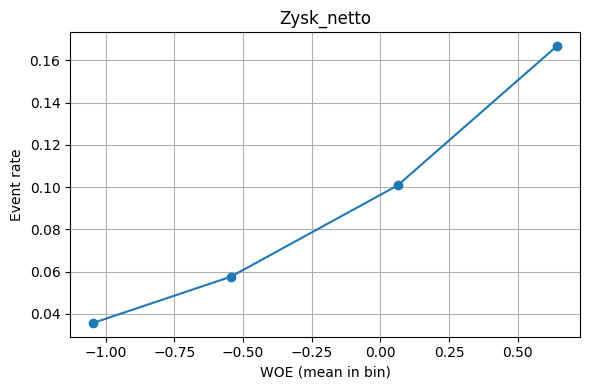

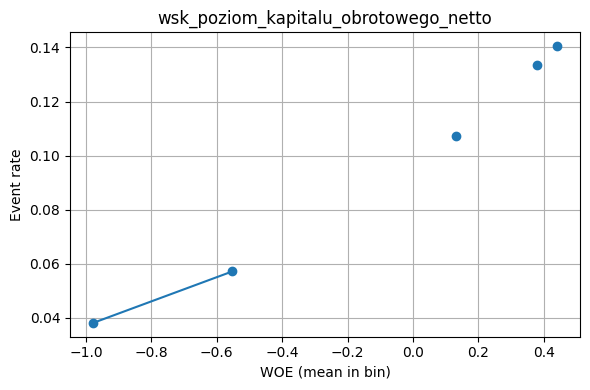

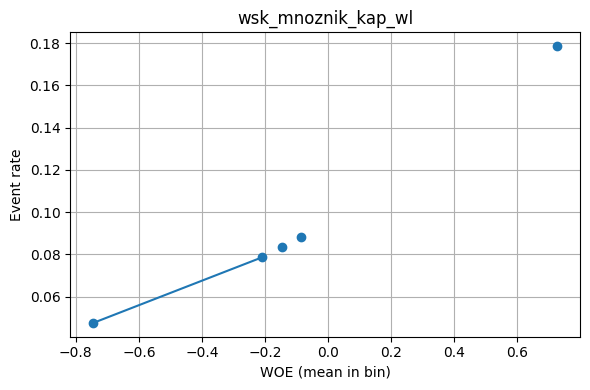

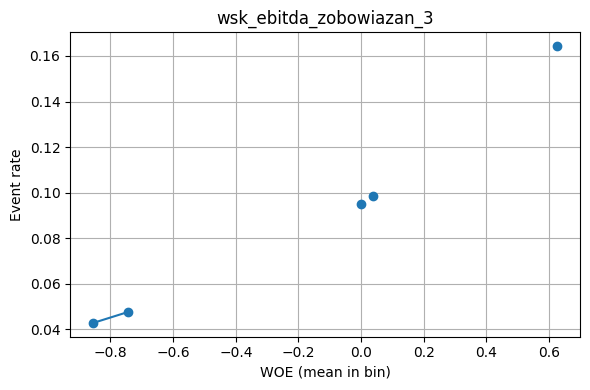

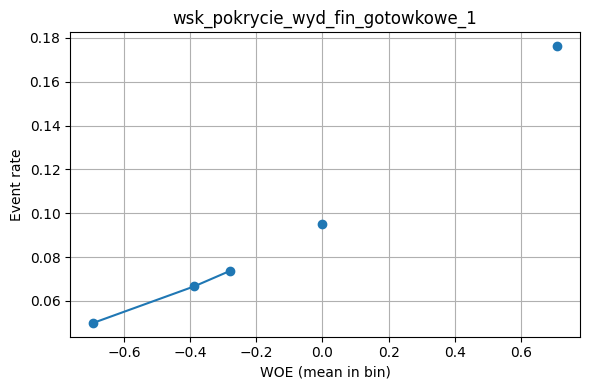

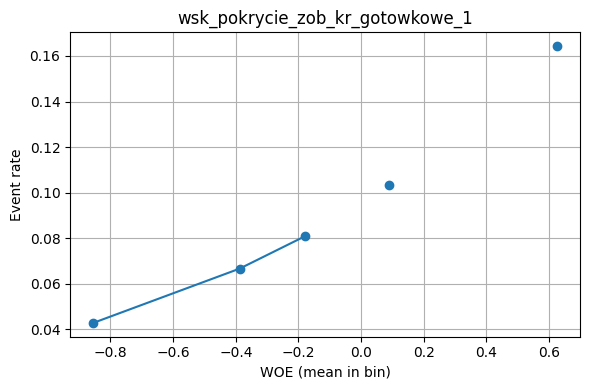

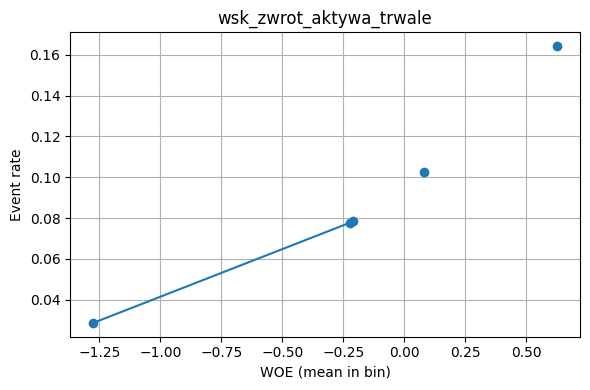

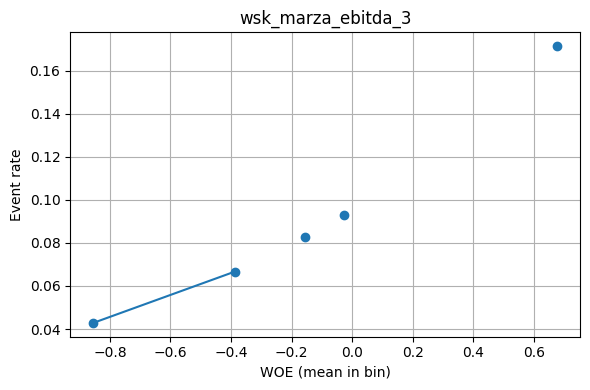

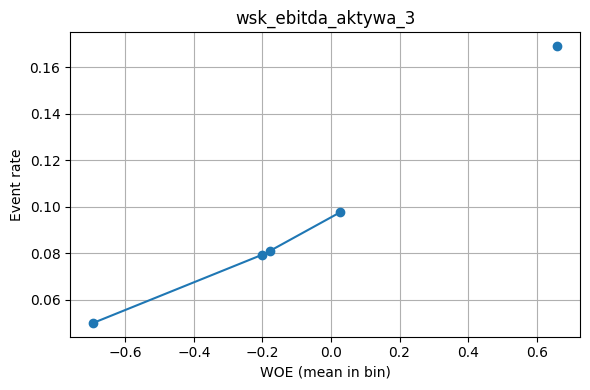

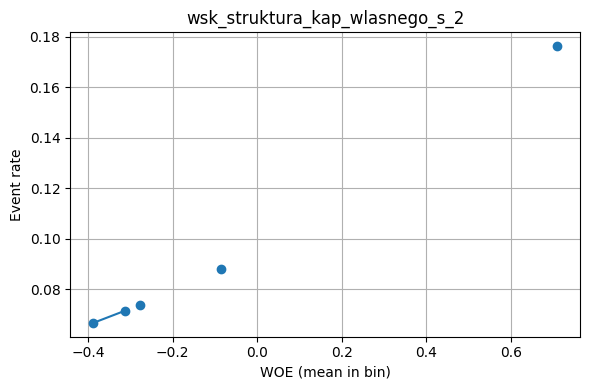

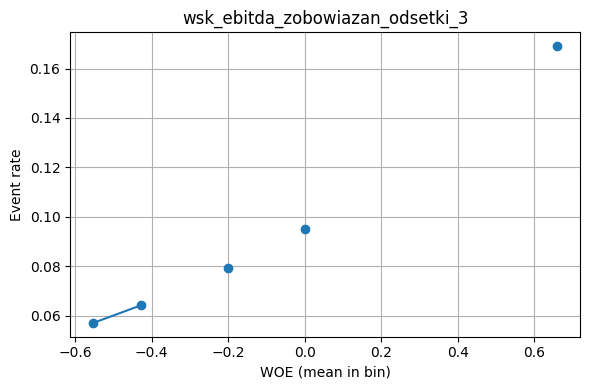

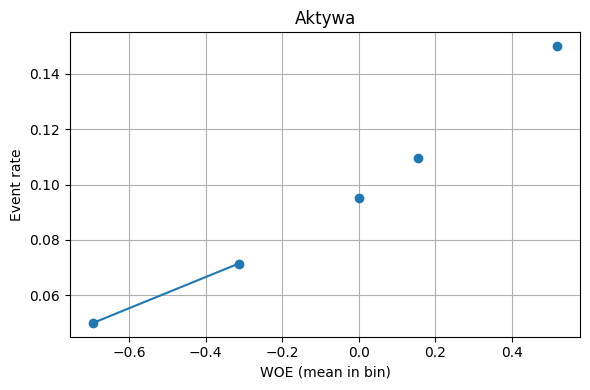

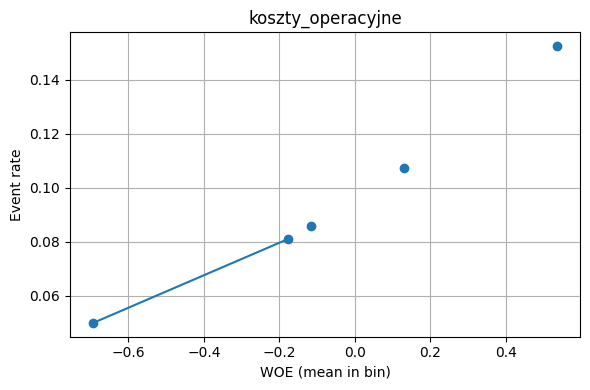

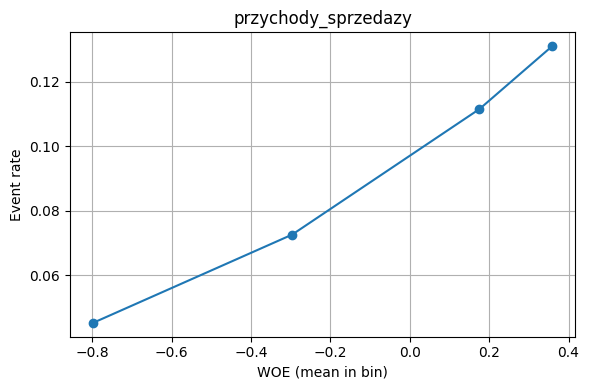

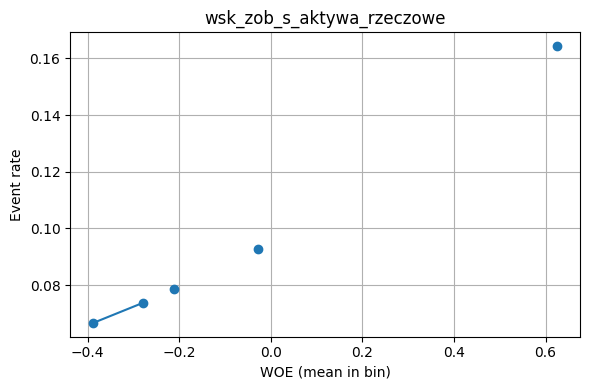

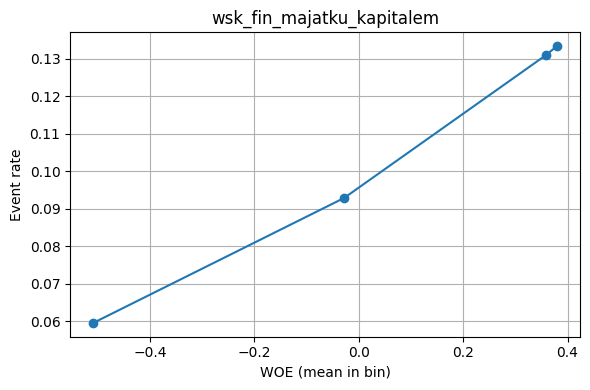

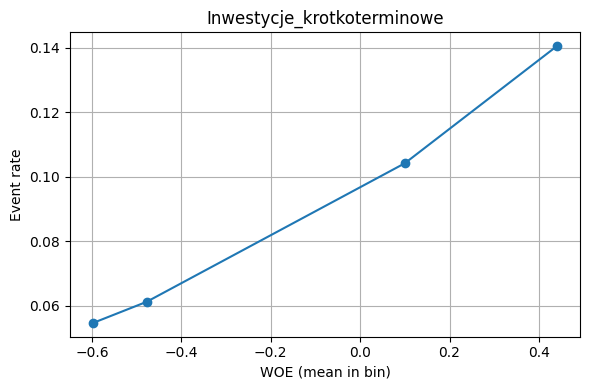

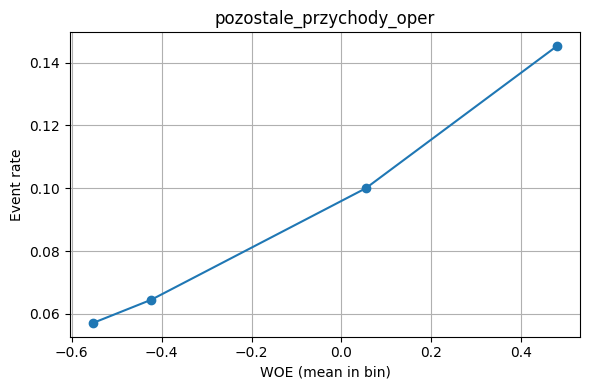

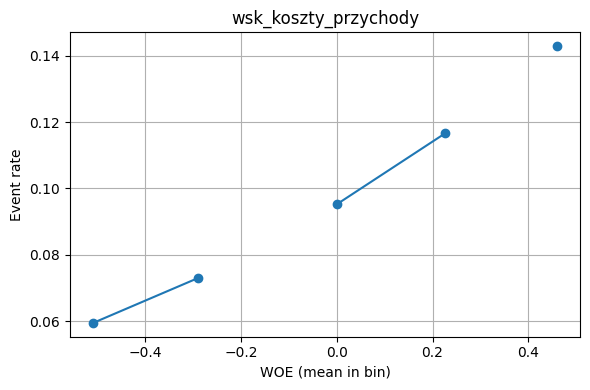

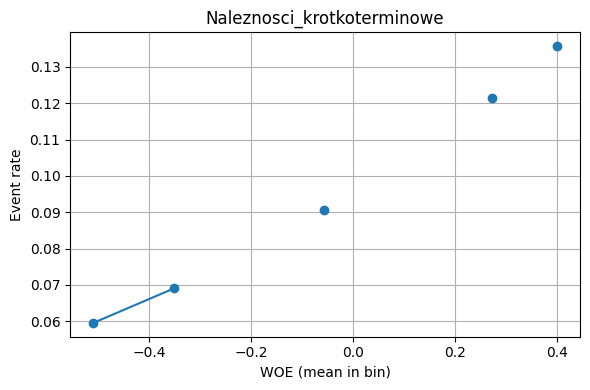

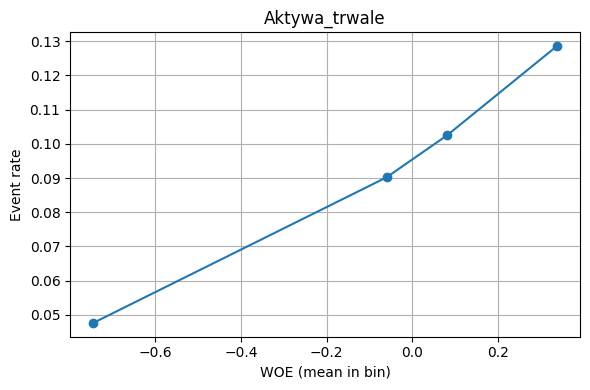

In [469]:
import matplotlib.pyplot as plt
def plot_all_woe_monotonicity(X, y, bins=10):
    
    y_vals = pd.Series(y).reset_index(drop=True)
    for feature in X.columns:
        feat_vals = X[feature].reset_index(drop=True)
        df = pd.DataFrame({feature: feat_vals, "_y": y_vals}).dropna()

        if df[feature].nunique() > 4:
            try:
                binned = pd.qcut(df[feature], q=bins, duplicates='drop')
            except ValueError:
                continue
        else:
            binned = df[feature]

        grouped_rate = df.groupby(binned)["_y"].mean()
        mean_woe = df.groupby(binned)[feature].mean()

        plt.figure(figsize=(6,4))
        plt.plot(mean_woe, grouped_rate, marker='o')
        plt.title(feature)
        plt.xlabel('WOE (mean in bin)')
        plt.ylabel('Event rate')
        plt.grid(True)
        plt.tight_layout()
        plt.show()

plot_all_woe_monotonicity(X_train_t, y_train)

In [470]:
df = X_train_t.copy()
df["_y"] = y_train.values if hasattr(y_train, "values") else y_train

unique_y_per_group = df.groupby(list(X_train_t.columns))["_y"].transform("nunique")

df_consistent = df[unique_y_per_group == 1]

df_final = df_consistent.drop_duplicates(subset=X_train_t.columns, keep="first").reset_index(drop=True)

X_train_t = df_final.drop(columns="_y")
y_train_t = df_final["_y"]
y_val_t = y_val
y_test_t = y_test

print("Początkowa liczba wierszy:", len(df))
print("Liczba po czyszczeniu:", len(df_final))
print("Usunięto wierszy:", len(df) - len(df_final))

Początkowa liczba wierszy: 2100
Liczba po czyszczeniu: 1946
Usunięto wierszy: 154


In [471]:
EPS = 1e-10

def analyze_woe_bins(X_woe, y,
                     min_bin_size=30,
                     woe_threshold=3.0,
                     iv_share_thresh=0.25,
                     spearman_thresh=0.8,
                     order_by='woe'):
    y = pd.Series(y).reset_index(drop=True)
    total_events = y.sum()
    total_non_events = (1 - y).sum()

    profiles = {}
    summary_rows = []

    for feature in X_woe.columns:
        ser = X_woe[feature].reset_index(drop=True)
        df = pd.DataFrame({feature: ser, '_y': y}).dropna()

        grp = df.groupby(feature)['_y'].agg(n='count', events='sum').reset_index().rename(columns={feature:'woe_value'})
        if grp.shape[0] == 0:
            continue

        grp['non_events'] = grp['n'] - grp['events']
        grp['event_rate'] = grp['events'] / grp['n']
        grp['event_dist'] = grp['events'] / (total_events)
        grp['non_event_dist'] = grp['non_events'] / (total_non_events)
        grp['prop_of_population'] = grp['n'] / (grp['n'].sum() + EPS)
        grp['woe'] = grp['woe_value'].astype(float)
        grp['iv_contrib'] = (grp['non_event_dist'] - grp['event_dist']) * grp['woe']

        if order_by == 'woe':
            grp = grp.sort_values('woe').reset_index(drop=True)
        elif order_by == 'event_rate':
            grp = grp.sort_values('event_rate').reset_index(drop=True)
        else:
            grp = grp.reset_index(drop=True)

        grp['cum_event_dist'] = grp['event_dist'].cumsum()
        grp['cum_non_event_dist'] = grp['non_event_dist'].cumsum()
        grp['ks'] = (grp['cum_non_event_dist'] - grp['cum_event_dist']).abs()
        grp['cum_iv'] = grp['iv_contrib'].cumsum()

        total_iv = grp['iv_contrib'].sum()

        try:
            spearman = spearmanr(grp['woe'], np.arange(len(grp)))[0]
        except Exception:
            spearman = np.nan

        grp['flag_small_bin'] = grp['n'] < min_bin_size
        grp['flag_zero_events'] = grp['events'] == 0
        grp['flag_zero_non_events'] = grp['non_events'] == 0
        grp['flag_extreme_woe'] = grp['woe'].abs() > woe_threshold
        grp['iv_share'] = 0.0 if abs(total_iv) < EPS else grp['iv_contrib'] / total_iv
        grp['flag_big_iv_share'] = grp['iv_share'].abs() > iv_share_thresh

        profiles[feature] = grp

        n_bins = grp.shape[0]
        n_small = int(grp['flag_small_bin'].sum())
        n_zero_events = int(grp['flag_zero_events'].sum())
        n_zero_non = int(grp['flag_zero_non_events'].sum())
        n_extreme = int(grp['flag_extreme_woe'].sum())
        n_big_iv = int(grp['flag_big_iv_share'].sum())
        max_ks = float(grp['ks'].max())
        max_iv_share = float(grp['iv_share'].abs().max())
        non_monotonic_flag = (abs(spearman) < spearman_thresh) if not np.isnan(spearman) else True

        summary_rows.append({
            'feature': feature,
            'n_bins': n_bins,
            'total_iv': total_iv,
            'spearman': spearman,
            'non_monotonic': non_monotonic_flag,
            'n_small_bins': n_small,
            'n_bins_zero_events': n_zero_events,
            'n_bins_zero_non_events': n_zero_non,
            'n_extreme_woe_bins': n_extreme,
            'n_big_iv_bins': n_big_iv,
            'max_ks': max_ks,
            'max_iv_share': max_iv_share,
            'prop_pop_min': float(grp['prop_of_population'].min()),
            'prop_pop_max': float(grp['prop_of_population'].max())
        })

    summary = pd.DataFrame(summary_rows).sort_values('total_iv', ascending=False).reset_index(drop=True)
    return profiles, summary


In [472]:
profiles, summary = analyze_woe_bins(X_train_t, y_train_t)

In [473]:
summary

,feature,n_bins,total_iv,spearman,non_monotonic,n_small_bins,n_bins_zero_events,n_bins_zero_non_events,n_extreme_woe_bins,n_big_iv_bins,max_ks,max_iv_share,prop_pop_min,prop_pop_max
0,Aktywa_trwale,4,-0.120421,NaN,True,0,0,0,0,1,0.123853,0.724432,0.131038,0.440904
1,Naleznosci_krotkoterminowe,5,-0.130317,NaN,True,0,0,0,0,2,0.170866,0.361510,0.149538,0.214800
2,pozostale_przychody_oper,4,-0.138102,NaN,True,0,0,0,0,2,0.148497,0.450912,0.158787,0.412641
3,wsk_koszty_przychody,5,-0.138469,NaN,True,0,0,0,0,2,0.177491,0.397390,0.107914,0.250257
4,Inwestycje_krotkoterminowe,4,-0.146421,NaN,True,0,0,0,0,2,0.161069,0.404474,0.159301,0.432169
5,wsk_zob_s_aktywa_rzeczowe,5,-0.152718,NaN,True,0,0,0,0,1,0.170360,0.696767,0.164954,0.215313
6,wsk_fin_majatku_kapitalem,4,-0.156532,NaN,True,0,0,0,0,1,0.184659,0.562419,0.157246,0.412127
7,przychody_sprzedazy,4,-0.159764,NaN,True,0,0,0,0,1,0.171680,0.615477,0.190647,0.379239
8,koszty_operacyjne,5,-0.166688,NaN,True,0,0,0,0,2,0.173222,0.462332,0.140288,0.215827
9,Aktywa,5,-0.173064,NaN,True,0,0,0,0,2,0.174734,0.445299,0.161357,0.215827


In [474]:
def objective(trial):
    C = trial.suggest_loguniform('C', 1e-3, 10)

    penalty = trial.suggest_categorical('penalty', ['l1', 'l2'])

    # Stała lista solverów (BRAK dynamicznych!)
    solver = trial.suggest_categorical('solver', ['liblinear', 'lbfgs', 'saga'])

    # Penalizacja zgodna z solverem — jeśli nielegalne: prune trial
    if penalty == "l1" and solver not in ("liblinear", "saga"):
        raise optuna.TrialPruned()

    if penalty == "l2" and solver not in ("liblinear", "lbfgs", "saga"):
        raise optuna.TrialPruned()

    # dual tylko dla l2 + liblinear
    dual = False
    if penalty == 'l2' and solver == 'liblinear':
        dual = trial.suggest_categorical('dual', [True, False])

    max_iter = trial.suggest_int('max_iter', 200, 2000)
    tol = trial.suggest_loguniform('tol', 1e-6, 1e-2)
    class_weight = trial.suggest_categorical('class_weight', [None, 'balanced'])
    fit_intercept = trial.suggest_categorical('fit_intercept', [True, False])
    warm_start = trial.suggest_categorical('warm_start', [False, True])

    model = LogisticRegression(
        C=C,
        penalty=penalty,
        solver=solver,
        dual=dual if (penalty=='l2' and solver=='liblinear') else False,
        class_weight=class_weight,
        max_iter=max_iter,
        tol=tol,
        fit_intercept=fit_intercept,
        warm_start=warm_start,
        random_state=1,
    )

    cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=1)
    scores = cross_val_score(model, X_train_t, y_train_t, cv=cv, scoring='roc_auc')

    return scores.mean()


# -------------------------
# Tworzymy i optymalizujemy study
# -------------------------
dataset_name = "example_dataset"
metric = "ROC AUC"
all_results = []

study = optuna.create_study(direction='maximize')
study.optimize(objective, n_trials=200)

# -------------------------
# Historia prób w DataFrame
# -------------------------
df_study = study.trials_dataframe(attrs=("number", "value", "params", "state", "duration"))
df_study["dataset"] = dataset_name
df_study["metric"] = metric
all_results.append(df_study)

# -------------------------
# Informacje o najlepszym trialu
# -------------------------
print(f"\n=== {dataset_name.upper()} ===")
print(f"Best {metric}: {study.best_value:.4f}")
print(f"Best params: {study.best_params}\n")

# -------------------------
# Wizualizacje interaktywne w notebooku
# -------------------------
fig1 = vis.plot_optimization_history(study)
fig2 = vis.plot_parallel_coordinate(study)
fig3 = vis.plot_contour(study)
fig3.update_layout(width=1100, height=700)




[I 2025-11-28 20:07:43,850] A new study created in memory with name: no-name-89966cc2-acde-463e-b735-5d840b7391cd
[I 2025-11-28 20:07:43,975] Trial 0 finished with value: 0.7190349730363893 and parameters: {'C': 0.25103474967140915, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 1624, 'tol': 0.00011256552135927731, 'class_weight': 'balanced', 'fit_intercept': False, 'warm_start': False}. Best is trial 0 with value: 0.7190349730363893.
[I 2025-11-28 20:07:44,028] Trial 1 finished with value: 0.7256709774415157 and parameters: {'C': 2.440892600346163, 'penalty': 'l1', 'solver': 'liblinear', 'max_iter': 1416, 'tol': 0.0012288917254957346, 'class_weight': None, 'fit_intercept': False, 'warm_start': False}. Best is trial 1 with value: 0.7256709774415157.
[I 2025-11-28 20:07:44,069] Trial 2 finished with value: 0.7264221825482449 and parameters: {'C': 0.0021365800916400297, 'penalty': 'l2', 'solver': 'lbfgs', 'max_iter': 429, 'tol': 8.76693588075155e-06, 'class_weight': None, 'fit_intercept


=== EXAMPLE_DATASET ===
Best ROC AUC: 0.7342
Best params: {'C': 0.016100797997287076, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 631, 'tol': 3.203245654590829e-05, 'class_weight': None, 'fit_intercept': False, 'warm_start': True}



In [475]:
# ---------------------------------------------------------
# 3️⃣ Predykcje
# ---------------------------------------------------------
best_params = study.best_params
print('best params', best_params)
best_model = LogisticRegression(
    **best_params,
    random_state=1
)

best_model.fit(X_train_t, y_train_t)
y_proba_train = best_model.predict_proba(X_train_t)[:, 1]
y_proba_val = best_model.predict_proba(X_val_t)[:, 1]
y_proba_test = best_model.predict_proba(X_test_t)[:, 1]

best params {'C': 0.016100797997287076, 'penalty': 'l2', 'solver': 'saga', 'max_iter': 631, 'tol': 3.203245654590829e-05, 'class_weight': None, 'fit_intercept': False, 'warm_start': True}


In [476]:
# ---------------------------------------------------------
# 4️⃣ Funkcja do liczenia nowych metryk
# ---------------------------------------------------------

import numpy as np
from sklearn.metrics import roc_auc_score, precision_recall_curve, auc, log_loss, roc_curve

def ks_stat_manual(y_true, y_proba):
    """
    KS statistic (ręczna wersja z dystrybuantami)
    """
    y_true = np.array(y_true)
    y_proba = np.array(y_proba)
    
    pos = y_proba[y_true == 1]
    neg = y_proba[y_true == 0]
    
    all_scores = np.sort(np.concatenate([pos, neg]))
    pos_cdf = np.searchsorted(np.sort(pos), all_scores, side='right') / len(pos)
    neg_cdf = np.searchsorted(np.sort(neg), all_scores, side='right') / len(neg)
    
    ks_value = np.max(np.abs(pos_cdf - neg_cdf))
    return ks_value

def ks_stat_roc(y_true, y_proba):
    """
    KS statistic używając roc_curve (szybsza i czytelniejsza)
    """
    fpr, tpr, _ = roc_curve(y_true, y_proba)
    return np.max(np.abs(tpr - fpr))

def compute_metrics(y_true, y_proba, use_roc_for_ks=True):
    """
    Compute common classification metrics: ROC AUC, PR AUC, KS statistic, Log-loss.
    
    Parameters:
    ----------
    y_true : array-like of shape (n_samples,)
        True binary labels (0 or 1)
    y_proba : array-like of shape (n_samples,)
        Predicted probabilities for the positive class
    use_roc_for_ks : bool
        If True, use roc_curve to compute KS (faster and standard). 
        If False, use manual dystrybuanta method.
    
    Returns:
    -------
    dict
        Dictionary with keys: 'ROC AUC', 'PR AUC', 'KS', 'Log-loss'
    """
    
    # ROC AUC
    roc_auc = roc_auc_score(y_true, y_proba)

    # PR-AUC
    precision, recall, _ = precision_recall_curve(y_true, y_proba)
    pr_auc = auc(recall, precision)

    # KS statistic
    ks = ks_stat_roc(y_true, y_proba) if use_roc_for_ks else ks_stat_manual(y_true, y_proba)

    # Log-loss
    ll = log_loss(y_true, y_proba)

    return {
        "ROC AUC": roc_auc,
        "PR AUC": pr_auc,
        "KS": ks,
        "Log-loss": ll
    }

train_metrics = compute_metrics(y_train_t, y_proba_train)
val_metrics = compute_metrics(y_val_t, y_proba_val)
test_metrics = compute_metrics(y_test_t, y_proba_test)

# ---------------------------------------------------------
# 5️⃣ Tabela porównawcza
# ---------------------------------------------------------

results_df = pd.DataFrame([train_metrics, val_metrics, test_metrics], index=["Train", "Validation","Test"]).T

results_df = results_df.round(4)


results_df

,Train,Validation,Test
ROC AUC,0.7415,0.8076,0.7122
PR AUC,0.2268,0.3315,0.2192
KS,0.3968,0.4675,0.3127
Log-loss,0.6055,0.5487,0.5892


### Testy monotoniczności kierunków wpływu

In [477]:
def get_model_statistics(model, X_train, feature_names):
    coefs = model.coef_[0]
    intercept = model.intercept_

    params = np.r_[intercept, coefs]

    n = len(X_train)
    X_design = np.hstack([np.ones((n, 1)), X_train])

    probs = model.predict_proba(X_train)[:, 1]

    W = probs * (1 - probs)

    Hessian = np.dot(X_design.T, W[:, None] * X_design)

    cov_matrix = np.linalg.inv(Hessian)

    std_errors = np.sqrt(np.diag(cov_matrix))

    z_scores = params / std_errors

    p_values = stats.norm.sf(np.abs(z_scores)) * 2

    ci_lower = params - 1.96 * std_errors
    ci_upper = params + 1.96 * std_errors

    all_names = ['Intercept'] + list(feature_names)
    
    summary_df = pd.DataFrame({
        'Zmienna': all_names,
        'Współczynnik (Beta)': params,
        'Odds Ratio': np.exp(params),
        'P-value': p_values.round(4),
        'CI Dolny (2.5%)': ci_lower,
        'CI Górny (97.5%)': ci_upper
    })
    summary_df = summary_df.sort_values(by='Współczynnik (Beta)', ascending=False).reset_index(drop=True)
    
    return summary_df

In [478]:
final_stats = get_model_statistics(best_model, X_train_t, X_train_t.columns)
final_stats

,Zmienna,Współczynnik (Beta),Odds Ratio,P-value,CI Dolny (2.5%),CI Górny (97.5%)
0,wsk_poziom_kapitalu_obrotowego_netto,0.332299,1.394169,0.0168,0.059942,0.604656
1,wsk_mnoznik_kap_wl,0.330737,1.391994,0.0436,0.009560,0.651914
2,Aktywa,0.325651,1.384932,0.2141,-0.188125,0.839426
3,Aktywa_trwale,0.241492,1.273148,0.2237,-0.147478,0.630462
4,wsk_pokrycie_wyd_fin_gotowkowe_1,0.226011,1.253589,0.1837,-0.107220,0.559241
5,wsk_fin_majatku_kapitalem,0.217647,1.243149,0.1854,-0.104493,0.539787
6,wsk_zob_s_aktywa_rzeczowe,0.201485,1.223218,0.3317,-0.205346,0.608316
7,pozostale_przychody_oper,0.185359,1.203650,0.2414,-0.124775,0.495493
8,wsk_zwrot_aktywa_trwale,0.181703,1.199257,0.1784,-0.082972,0.446378
9,wsk_struktura_kap_wlasnego_s_2,0.178169,1.195028,0.4055,-0.241608,0.597947


### Mamy dużo wysokich p-wartości. Usuńmy zmienne aż wszystkie w modelu będą adekwatne.

In [479]:
class WaldSelector(BaseEstimator, TransformerMixin):
    def __init__(self, threshold=0.05):
        self.threshold = threshold
        self.selected_features_ = []
        self.model_summary_ = None 
        
    def fit(self, X, y):
        features = list(X.columns)
        
        while len(features) > 0:
            X_current = X[features].copy()
            X_const = sm.add_constant(X_current)
            model = sm.Logit(y, X_const).fit(disp=0)
            p_values = model.pvalues

            if 'const' in p_values:
                p_values = p_values.drop('const')

            max_p_value = p_values.max()
            worst_feature = p_values.idxmax()

            if max_p_value > self.threshold:
                features.remove(worst_feature)
            else:
                self.model_summary_ = model.summary() 
                break

        self.selected_features_ = features
        return self

    def transform(self, X):
        return X[self.selected_features_]

In [480]:
selector = WaldSelector(threshold=0.05)
selector.fit(X_train_t, y_train_t)
X_train_final = selector.transform(X_train_t)
X_val_final = selector.transform(X_val_t)
X_test_final = selector.transform(X_test_t)


In [481]:
y_train_final = y_train_t
y_val_final = y_val_t
y_test_final = y_test_t

### Interpretacja globalna

RANKING WAŻNOŚCI CECH:
                             Zmienna  Beta (Współczynnik)  Ważność %
                  wsk_mnoznik_kap_wl                 0.99      27.83
                       Aktywa_trwale                 0.67      18.73
wsk_poziom_kapitalu_obrotowego_netto                 0.52      14.46
                   koszty_operacyjne                 0.50      14.01
             wsk_zwrot_aktywa_trwale                 0.49      13.72
    wsk_pokrycie_wyd_fin_gotowkowe_1                 0.40      11.24


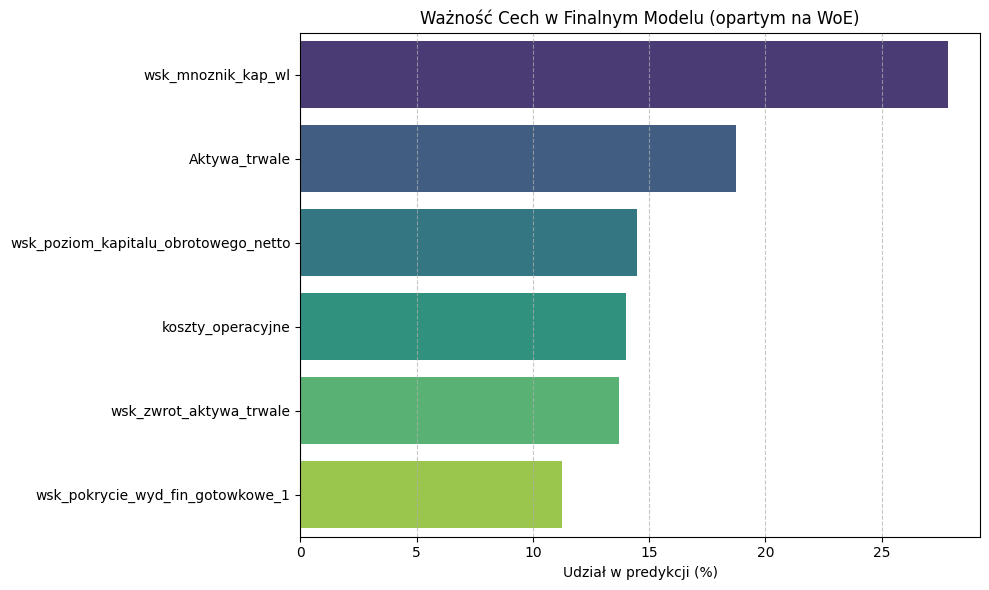

In [482]:
final_model = LogisticRegression(fit_intercept=True, solver='newton-cg')
final_model.fit(X_train_final, y_train_final)

feature_names = X_train_final.columns
coefficients = final_model.coef_[0]

importance_df = pd.DataFrame({
    'Zmienna': feature_names,
    'Beta (Współczynnik)': coefficients,
    'Wpływ (Abs Beta)': np.abs(coefficients) 
})

total_importance = importance_df['Wpływ (Abs Beta)'].sum()
importance_df['Ważność %'] = (importance_df['Wpływ (Abs Beta)'] / total_importance) * 100

importance_df = importance_df.sort_values(by='Ważność %', ascending=False)

print("RANKING WAŻNOŚCI CECH:")
print(importance_df[['Zmienna', 'Beta (Współczynnik)', 'Ważność %']].to_string(index=False, float_format="%.2f"))

plt.figure(figsize=(10, 6))
sns.barplot(data=importance_df, x='Ważność %', y='Zmienna', palette='viridis')
plt.title('Ważność Cech w Finalnym Modelu (opartym na WoE)')
plt.xlabel('Udział w predykcji (%)')
plt.ylabel('')
plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

In [483]:
def calculate_model_metrics(model, X_val, y_val):
    y_pred_proba = model.predict_proba(X_val)[:, 1]

    roc_auc = roc_auc_score(y_val, y_pred_proba)

    pr_auc = average_precision_score(y_val, y_pred_proba)

    probs_class_1 = y_pred_proba[y_val == 1]
    probs_class_0 = y_pred_proba[y_val == 0]

    ks_statistic, p_value = ks_2samp(probs_class_1, probs_class_0)
  
    ll = log_loss(y_val, y_pred_proba)

    brier = brier_score_loss(y_val, y_pred_proba)

    metrics_df = pd.DataFrame({
        'Metryka': ['AUC ROC', 'PR-AUC', 'KS Statistic', 'Log-loss', 'Brier Score'],
        'Wartość': [roc_auc, pr_auc, ks_statistic, ll, brier]
    })
    
    return metrics_df, y_pred_proba

metrics_table, probs = calculate_model_metrics(final_model, X_val_final, y_val)

print("WYNIKI MODELU NA ZBIORZE WALIDACYJNYM:")
print(metrics_table.to_string(index=False, float_format="%.4f"))

WYNIKI MODELU NA ZBIORZE WALIDACYJNYM:
     Metryka  Wartość
     AUC ROC   0.7688
      PR-AUC   0.2478
KS Statistic   0.4047
    Log-loss   0.2761
 Brier Score   0.0796


### Wykresy PDP/ICE 

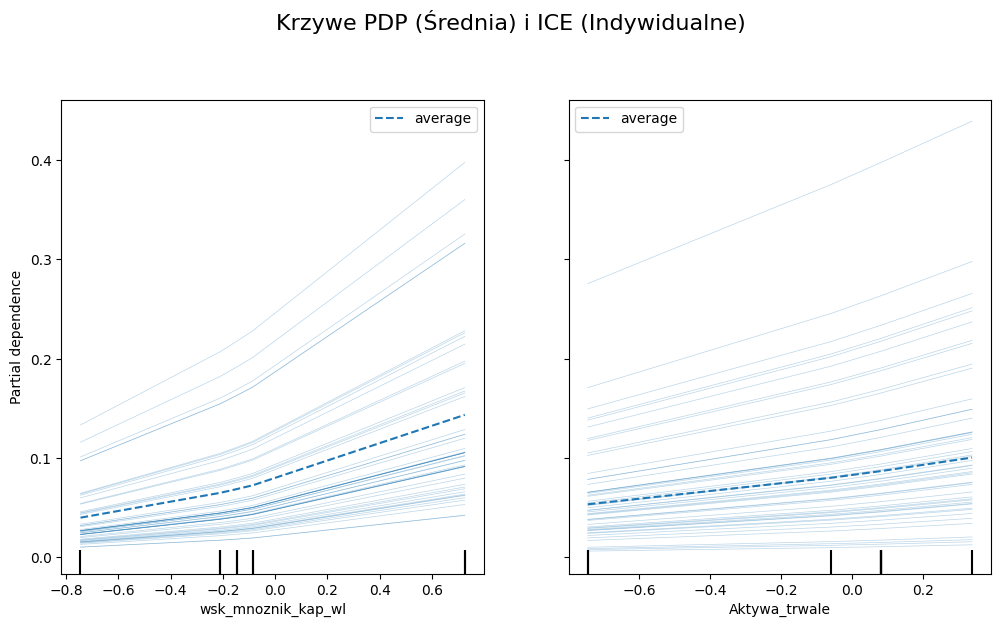

In [484]:
features_to_plot = ['wsk_mnoznik_kap_wl', 'Aktywa_trwale'] 

fig, ax = plt.subplots(figsize=(12, 6))

display = PartialDependenceDisplay.from_estimator(
    estimator=final_model,      
    X=X_val_final,            
    features=features_to_plot,  
    kind='both',              
    subsample=50,             
    n_jobs=-1,                 
    grid_resolution=20,      
    ax=ax
)

plt.suptitle('Krzywe PDP (Średnia) i ICE (Indywidualne)', fontsize=16, y=1.05)
plt.subplots_adjust(top=0.9) 
plt.show()

In [485]:
y_pred_class = final_model.predict(X_test_final)
y_pred_proba = final_model.predict_proba(X_test_final)[:, 1]

results_df = pd.DataFrame({
    'Rzeczywista_Klasa': y_test,
    'Przewidziana_Klasa': y_pred_class,
    'Prawdopodobienstwo': y_pred_proba
}, index=X_test.index)

predicted_ones = results_df[results_df['Przewidziana_Klasa'] == 1].sort_values(by='Prawdopodobienstwo', ascending=False)

print(f"Znaleziono {len(predicted_ones)} obserwacji przewidzianych jako 1.")

Znaleziono 0 obserwacji przewidzianych jako 1.


#### Obecnie model nie przewiduje żadnych wartości z prawdopodobieństwem 1, czyli trzeba zmienić progi
- przyjmując marżę ok. 20% na jednym kredycie mamy 5 krotnie większą stratę z jednego klienta niż zysk z jednego spłacalnego

In [546]:
COST_TP = 0   # odrzucamy złego klienta
COST_FP =  1   # koszt, gdy odrzucimy dobrego klienta - do zastanowienia się
COST_FN =  5  # koszt, gdy klient nie spłaci - do zastanowienia się
COST_TN =  -1  # zysk z udzieleniu kredytu dobremu klientowi

#### Na początek kalibracja

Generowanie diagnostyki na zbiorze walidacyjnym...


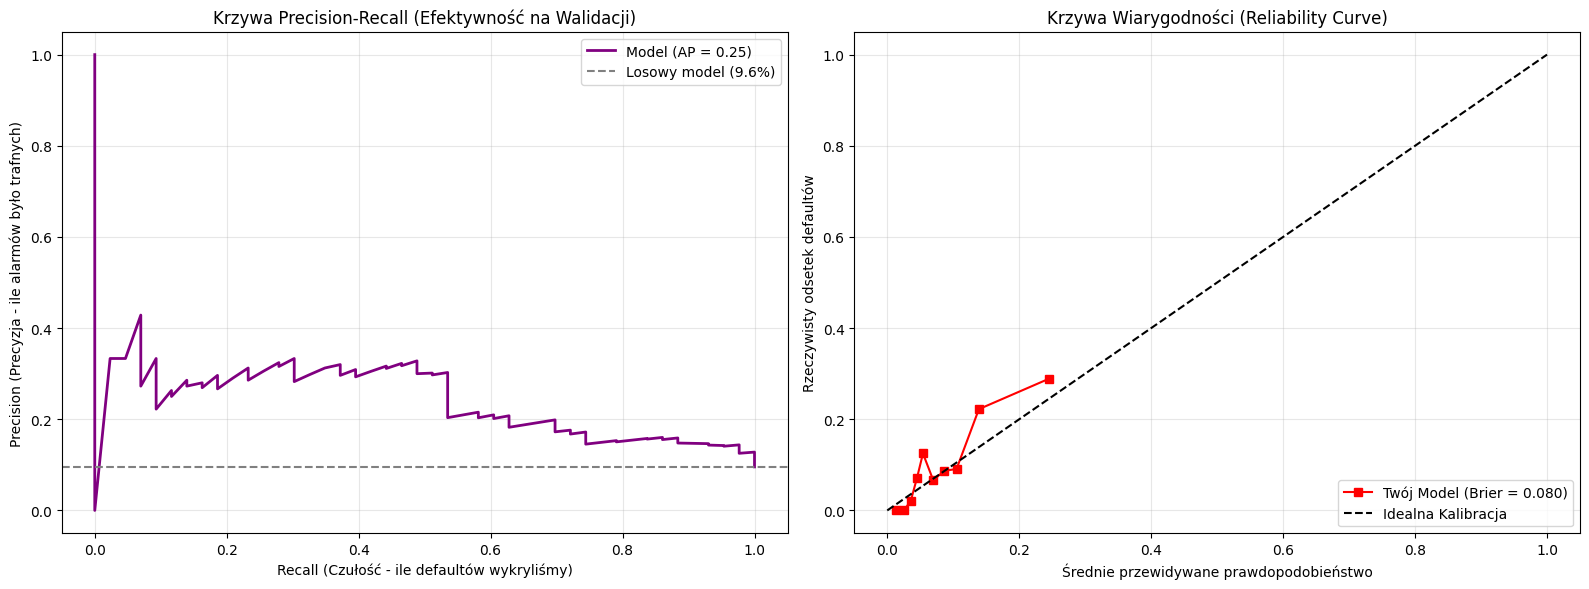

In [547]:
def plot_validation_diagnostics(model, X_val, y_val):
    probs_val = model.predict_proba(X_val)[:, 1]
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))
    precision, recall, _ = precision_recall_curve(y_val, probs_val)
    ap_score = average_precision_score(y_val, probs_val)
    ax1.plot(recall, precision, color='purple', lw=2, label=f'Model (AP = {ap_score:.2f})')
    baseline = y_val.mean()
    ax1.axhline(baseline, color='gray', linestyle='--', label=f'Losowy model ({baseline:.1%})')
    
    ax1.set_title('Krzywa Precision-Recall (Efektywność na Walidacji)')
    ax1.set_xlabel('Recall (Czułość - ile defaultów wykryliśmy)')
    ax1.set_ylabel('Precision (Precyzja - ile alarmów było trafnych)')
    ax1.legend(loc="upper right")
    ax1.grid(True, alpha=0.3)
    fraction_of_positives, mean_predicted_value = calibration_curve(y_val, probs_val, n_bins=10, strategy='quantile')
    brier = brier_score_loss(y_val, probs_val)
    
    ax2.plot(mean_predicted_value, fraction_of_positives, "s-", color='red', label=f'Twój Model (Brier = {brier:.3f})')
    ax2.plot([0, 1], [0, 1], "k--", label="Idealna Kalibracja")
    ax2.set_title('Krzywa Wiarygodności (Reliability Curve)')
    ax2.set_xlabel('Średnie przewidywane prawdopodobieństwo')
    ax2.set_ylabel('Rzeczywisty odsetek defaultów')
    ax2.legend(loc="lower right")
    ax2.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.show()

print("Generowanie diagnostyki na zbiorze walidacyjnym...")
plot_validation_diagnostics(final_model, X_val_final, y_val_final)

#### Model przeszacowuje ryzyko, krzywa precision-recall wypada bardzo słabo

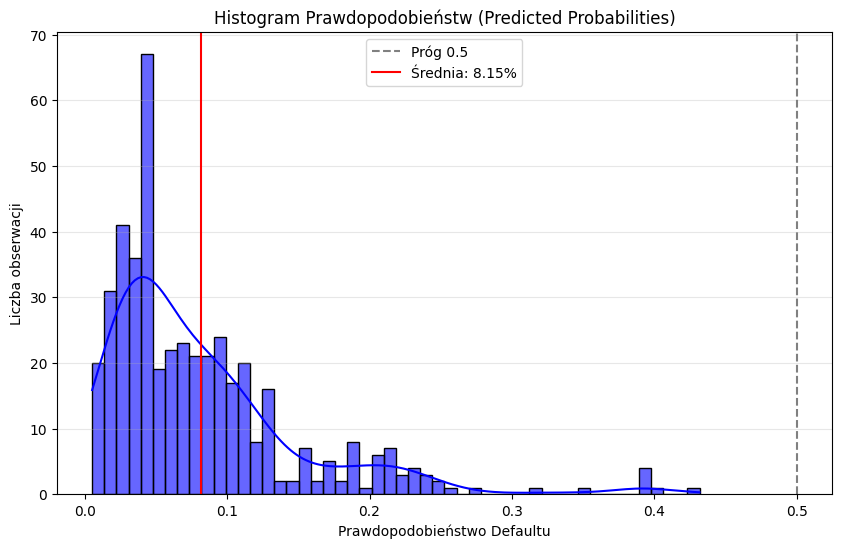

--- WYNIKI KALIBRACJI (na 10 koszykach) ---
ECE (Expected Calibration Error): 0.0160  (Mniej = Lepiej)
ACE (Adaptive Calibration Error): 0.0295  (Mniej = Lepiej)
----------------------------------------


In [548]:
def analyze_calibration_metrics(model, X, y_true, n_bins=10):
    probs = model.predict_proba(X)[:, 1]
    plt.figure(figsize=(10, 6))
    sns.histplot(probs, bins=50, kde=True, color='blue', alpha=0.6)
    plt.title('Histogram Prawdopodobieństw (Predicted Probabilities)')
    plt.xlabel('Prawdopodobieństwo Defaultu')
    plt.ylabel('Liczba obserwacji')
    plt.axvline(0.5, color='gray', linestyle='--', label='Próg 0.5')

    mean_prob = np.mean(probs)
    plt.axvline(mean_prob, color='red', linestyle='-', label=f'Średnia: {mean_prob:.2%}')
    plt.legend()
    plt.grid(axis='y', alpha=0.3)
    plt.show()

    prob_true_uni, prob_pred_uni = calibration_curve(y_true, probs, n_bins=n_bins, strategy='uniform')

    bin_counts, _ = np.histogram(probs, bins=np.linspace(0, 1, n_bins + 1))
    non_empty_bins = bin_counts > 0 

    weights = bin_counts[non_empty_bins] / len(probs)
 
    ece = np.average(np.abs(prob_pred_uni - prob_true_uni), weights=weights)

    prob_true_q, prob_pred_q = calibration_curve(y_true, probs, n_bins=n_bins, strategy='quantile')

    ace = np.mean(np.abs(prob_pred_q - prob_true_q))

    print(f"--- WYNIKI KALIBRACJI (na {n_bins} koszykach) ---")
    print(f"ECE (Expected Calibration Error): {ece:.4f}  (Mniej = Lepiej)")
    print(f"ACE (Adaptive Calibration Error): {ace:.4f}  (Mniej = Lepiej)")
    print("-" * 40)

analyze_calibration_metrics(final_model, X_val_final, y_val_final, n_bins=10)

#### Wykorzystanie kalibracji sigmoid - mało danych i zależności liniowe

Trwa kalibracja Platta na zbiorze walidacyjnym...

--- WYNIKI ---
Brier Score (Oryginał):     0.08029
Brier Score (Platt Scaling): 0.08117


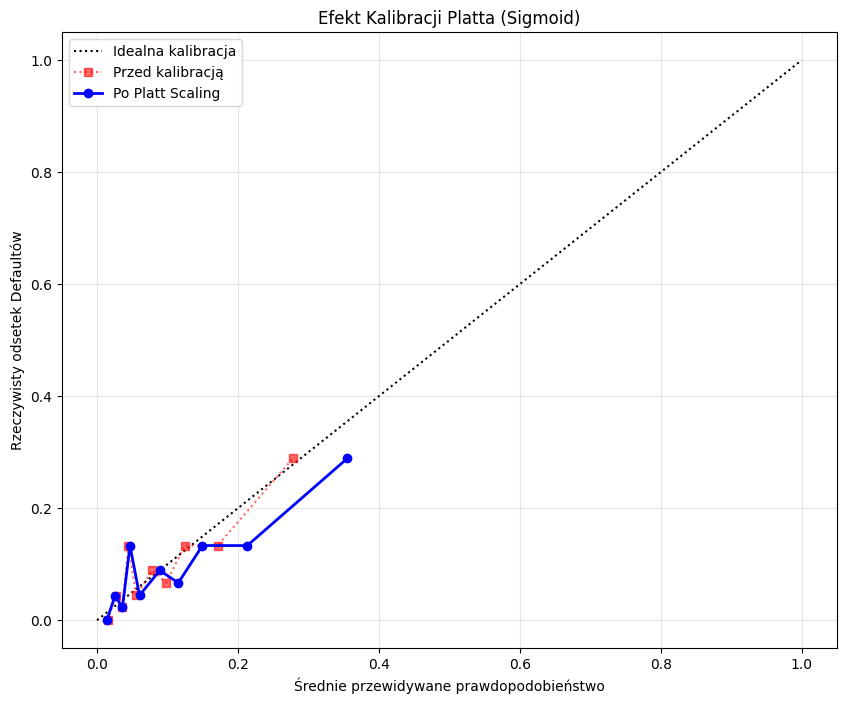

In [549]:
def perform_platt_scaling(model, X_calib, y_calib, X_test, y_test):
    platt_calibrator = CalibratedClassifierCV(model, method='sigmoid', cv='prefit')

    print("Trwa kalibracja Platta na zbiorze walidacyjnym...")
    platt_calibrator.fit(X_calib, y_calib)

    probs_original = model.predict_proba(X_test)[:, 1]
    probs_platt = platt_calibrator.predict_proba(X_test)[:, 1]

    brier_orig = brier_score_loss(y_test, probs_original)
    brier_platt = brier_score_loss(y_test, probs_platt)
    
    print(f"\n--- WYNIKI ---")
    print(f"Brier Score (Oryginał):     {brier_orig:.5f}")
    print(f"Brier Score (Platt Scaling): {brier_platt:.5f}")

    plt.figure(figsize=(10, 8))

    plt.plot([0, 1], [0, 1], "k:", label="Idealna kalibracja")

    frac_orig, mean_orig = calibration_curve(y_test, probs_original, n_bins=10, strategy="quantile")
    plt.plot(mean_orig, frac_orig, "s:", label="Przed kalibracją", color='red', alpha=0.6)

    frac_platt, mean_platt = calibration_curve(y_test, probs_platt, n_bins=10, strategy="quantile")
    plt.plot(mean_platt, frac_platt, "o-", label="Po Platt Scaling", color='blue', linewidth=2)
    
    plt.ylabel("Rzeczywisty odsetek Defaultów")
    plt.xlabel("Średnie przewidywane prawdopodobieństwo")
    plt.title("Efekt Kalibracji Platta (Sigmoid)")
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()
    
    return platt_calibrator

final_platt_model = perform_platt_scaling(
    model=final_model,
    X_calib=X_val_final, 
    y_calib=y_val,
    X_test=X_test_final,
    y_test=y_test
)

In [550]:
inner_obj = final_platt_model.calibrated_classifiers_[0]

sigmoid_calibrator = inner_obj.calibrators[0]

A = sigmoid_calibrator.a_
B = sigmoid_calibrator.b_

#### Strojenie interceptu

In [551]:
class CalibrationInTheLargeWrapper(BaseEstimator, ClassifierMixin):
    def __init__(self, base_model, target_mean=0.04):
        self.base_model = base_model
        self.target_mean = target_mean
        self.offset_ = 0.0
        
    def fit(self, X, y=None):
        raw_probs = self.base_model.predict_proba(X)[:, 1]

        eps = 1e-15
        raw_probs = np.clip(raw_probs, eps, 1 - eps)

        raw_logits = logit(raw_probs)

        def error_func(delta):
            new_probs = expit(raw_logits + delta)
            return np.mean(new_probs) - self.target_mean
        
        self.offset_ = newton(error_func, x0=0.0)
            
        print(f"Model skalibrowany do średniej {self.target_mean:.2%}. Wyliczony offset: {self.offset_:.6f}")
        return self


    def _get_platt_and_linear_params(self):

        calibrated_clf = self.base_model.calibrated_classifiers_[0]

        platt_calibrator = calibrated_clf.calibrators[0]
        A = platt_calibrator.a_
        B = platt_calibrator.b_

        linear_model = calibrated_clf.estimator
        w = linear_model.coef_
        b = linear_model.intercept_
        
        return A, B, w, b

    @property
    def coef_(self):
        A, _, w, _ = self._get_platt_and_linear_params()
        return -A * w

    @property
    def intercept_(self):
        A, B, _, b = self._get_platt_and_linear_params()
        if isinstance(b, (list, np.ndarray)):
            b = b[0]
            
        return (-A * b) - B + self.offset_

    def predict_proba(self, X):
        probs = self.base_model.predict_proba(X)[:, 1]
        eps = 1e-15
        probs = np.clip(probs, eps, 1 - eps)
        logits = logit(probs)
        corrected_logits = logits + self.offset_
        final_probs = expit(corrected_logits)
        return np.vstack([1 - final_probs, final_probs]).T

    def predict(self, X, threshold=0.5):
        probs = self.predict_proba(X)[:, 1]
        return (probs >= threshold).astype(int)

In [552]:
final_calibrated_model = CalibrationInTheLargeWrapper(
    base_model=final_platt_model,  
    target_mean=0.04         
)

In [553]:
final_calibrated_model.fit(X_val_final)

Model skalibrowany do średniej 4.00%. Wyliczony offset: -1.003227


,base_model,CalibratedCla...='newton-cg'))
,target_mean,0.04
,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'newton-cg'


#### Diagnostyka modelu po kalibracji

=== RAPORT WALIDACJI 'POST-CAL' ===

1. Globalna Stabilność (Calibration-in-the-large)
   Średnia Predykcja (PD):  4.7241%
2. Jakość Dopasowania
   Brier Score: 0.08326 (Im mniej tym lepiej)
   AUC ROC:     0.7193   (Powinno być takie samo jak przed kalibracją)

3. Błędy Kalibracji (Calibration-in-the-small)
   ECE (Expected Error): 0.0497
   ACE (Adaptive Error): 0.0493


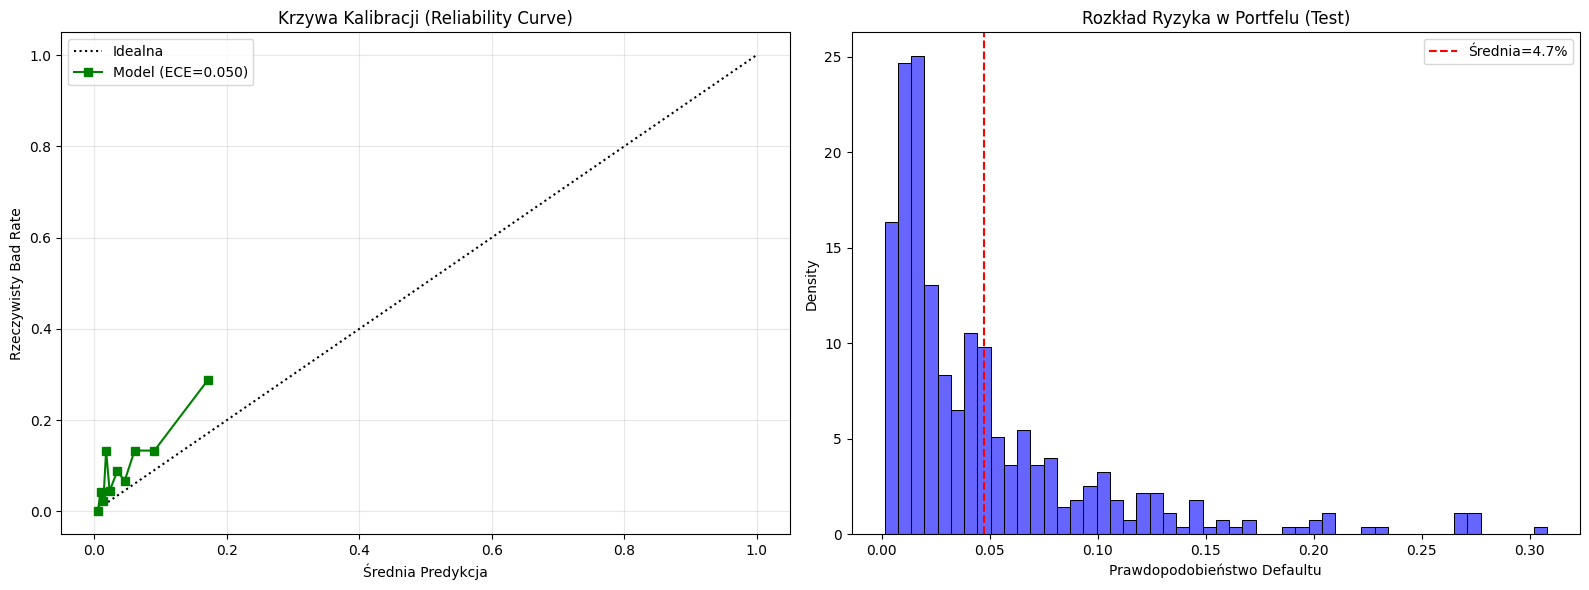

In [554]:
def evaluate_post_calibration(model, X, y, segment_col=None):
    if hasattr(model, "predict_proba"):
        probs = model.predict_proba(X)[:, 1]
    else:
        probs = model.predict(X) 
        
    print("=== RAPORT WALIDACJI 'POST-CAL' ===\n")

    mean_pred = np.mean(probs)
    mean_actual = np.mean(y)
    brier = brier_score_loss(y, probs)
    auc = roc_auc_score(y, probs)
    
    print(f"1. Globalna Stabilność (Calibration-in-the-large)")
    print(f"   Średnia Predykcja (PD):  {mean_pred:.4%}")
    
    print(f"2. Jakość Dopasowania")
    print(f"   Brier Score: {brier:.5f} (Im mniej tym lepiej)")
    print(f"   AUC ROC:     {auc:.4f}   (Powinno być takie samo jak przed kalibracją)\n")

    def calculate_errors(y_true, y_prob, n_bins=10):
        prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='uniform')
        bin_counts, _ = np.histogram(y_prob, bins=np.linspace(0, 1, n_bins + 1))
        weights = bin_counts[bin_counts > 0] / len(y_prob)
        ece = np.average(np.abs(prob_pred - prob_true), weights=weights)
        prob_true_q, prob_pred_q = calibration_curve(y_true, y_prob, n_bins=n_bins, strategy='quantile')
        ace = np.mean(np.abs(prob_pred_q - prob_true_q))
        return ece, ace, prob_true_q, prob_pred_q

    ece, ace, curve_true, curve_pred = calculate_errors(y, probs)
    print(f"3. Błędy Kalibracji (Calibration-in-the-small)")
    print(f"   ECE (Expected Error): {ece:.4f}")
    print(f"   ACE (Adaptive Error): {ace:.4f}")

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

    ax1.plot([0, 1], [0, 1], "k:", label="Idealna")
    ax1.plot(curve_pred, curve_true, "s-", color='green', label=f'Model (ECE={ece:.3f})')
    ax1.set_xlabel("Średnia Predykcja")
    ax1.set_ylabel("Rzeczywisty Bad Rate")
    ax1.set_title("Krzywa Kalibracji (Reliability Curve)")
    ax1.legend()
    ax1.grid(True, alpha=0.3)

    sns.histplot(probs, bins=50, ax=ax2, color='blue', alpha=0.6, stat='density')
    ax2.axvline(mean_pred, color='red', linestyle='--', label=f'Średnia={mean_pred:.1%}')
    ax2.set_xlabel("Prawdopodobieństwo Defaultu")
    ax2.set_title("Rozkład Ryzyka w Portfelu (Test)")
    ax2.legend()
    
    plt.tight_layout()
    plt.show()

evaluate_post_calibration(final_calibrated_model, X_test_final, y_test_final)

### Progi decyzyjne

In [555]:
def cost_for_threshold(y_true, p, thr):
    yhat = (p >= thr).astype(int)
    
    tp = np.sum((yhat==1) & (y_true==1)) 
    fp = np.sum((yhat==1) & (y_true==0)) 
    fn = np.sum((yhat==0) & (y_true==1)) 
    tn = np.sum((yhat==0) & (y_true==0)) 

    total_cost = (tp * COST_TP) + (fp * COST_FP) + (fn * COST_FN) + (tn * COST_TN)
    
    return total_cost, tp, fp, fn, tn

def sweep_costs(y_true, p, n=1001):
    thrs = np.linspace(0, 1, n)
    costs, details = [], []
    for t in thrs:
        c, tp, fp, fn, tn = cost_for_threshold(y_true, p, t)
        costs.append(c)
        details.append((tp, fp, fn, tn))
    return thrs, np.array(costs), details

y_probs = final_calibrated_model.predict_proba(X_val_final)[:, 1]

thrs, costs, details = sweep_costs(y_val_final, y_probs)

best_idx = int(np.argmin(costs))
best_thr = float(thrs[best_idx])
print(f"Wyznaczony Optymalny Próg: {best_thr:.4f}")
min_cost = costs[best_idx]
best_tp, best_fp, best_fn, best_tn = details[best_idx]

max_profit = -min_cost 


Wyznaczony Optymalny Próg: 0.0660


Całkowity Wynik Finansowy (Zysk): 142 jednostek
Decyzje:
 - Udzielone: 348 (Accept Rate: 77.33%)
 - Odrzucone: 102
Jakość Portfela Kredytowego:
 - Dobre kredyty (Zysk): 327
 - Złe kredyty (Strata): 21 (Realny Default Rate w portfelu: 6.03%)


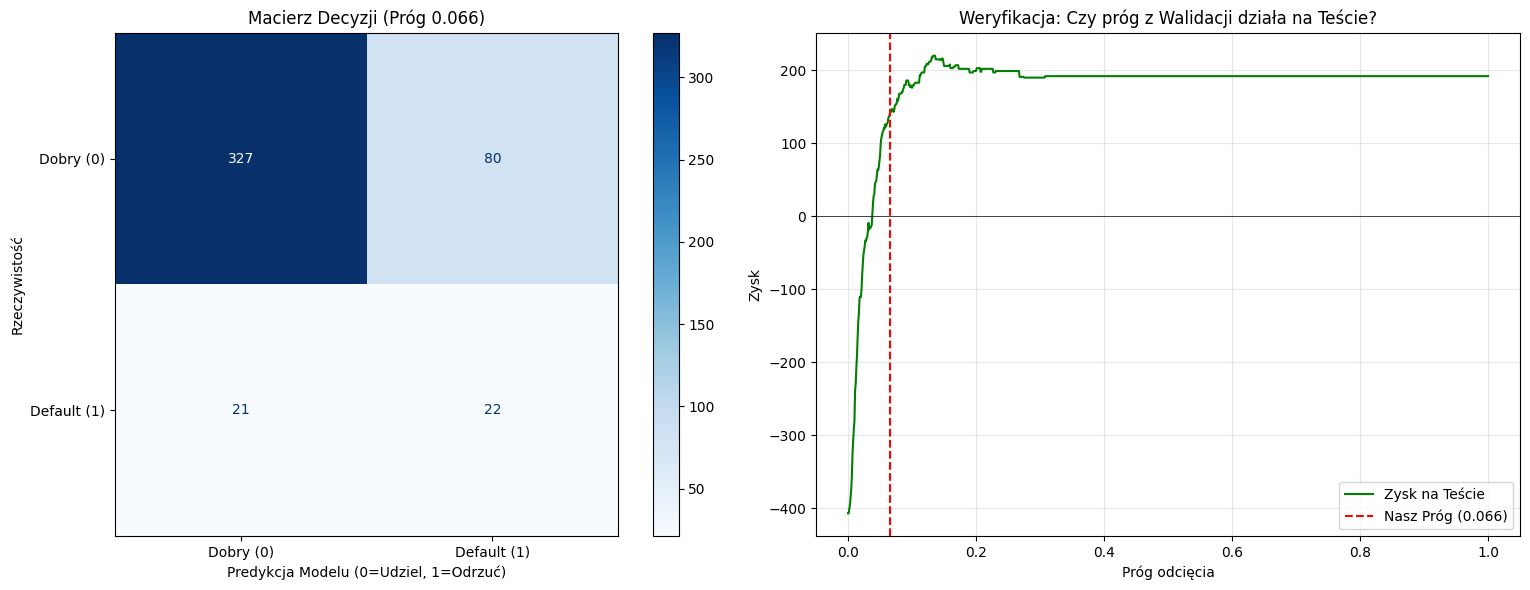

In [556]:
y_probs_test = final_calibrated_model.predict_proba(X_test_final)[:, 1]

test_cost, tp, fp, fn, tn = cost_for_threshold(y_test_final, y_probs_test, best_thr)
test_profit = -test_cost 

total_loans = tn + fn
total_rejected = tp + fp
accept_rate = total_loans / len(y_test)
default_rate_portfolio = fn / total_loans if total_loans > 0 else 0

print(f"Całkowity Wynik Finansowy (Zysk): {test_profit:,.0f} jednostek")
print(f"Decyzje:")
print(f" - Udzielone: {total_loans} (Accept Rate: {accept_rate:.2%})")
print(f" - Odrzucone: {total_rejected}")
print(f"Jakość Portfela Kredytowego:")
print(f" - Dobre kredyty (Zysk): {tn}")
print(f" - Złe kredyty (Strata): {fn} (Realny Default Rate w portfelu: {default_rate_portfolio:.2%})")

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

cm = np.array([[tn, fp], [fn, tp]])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Dobry (0)', 'Default (1)'])
disp.plot(cmap='Blues', ax=ax1, values_format='d')
ax1.set_title(f'Macierz Decyzji (Próg {best_thr:.3f})')
ax1.set_xlabel('Predykcja Modelu (0=Udziel, 1=Odrzuć)')
ax1.set_ylabel('Rzeczywistość')

t_test, c_test, _ = sweep_costs(y_test_final, y_probs_test)
ax2.plot(t_test, -c_test, color='green', label='Zysk na Teście')
ax2.axvline(best_thr, color='red', linestyle='--', label=f'Nasz Próg ({best_thr:.3f})')
ax2.axhline(0, color='black', linewidth=0.5)
ax2.set_title('Weryfikacja: Czy próg z Walidacji działa na Teście?')
ax2.set_xlabel('Próg odcięcia')
ax2.set_ylabel('Zysk')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

#### Finalny model do interpretowalności

In [557]:
class FinalBusinessModel(BaseEstimator, ClassifierMixin):
    def __init__(self, model, threshold=0.5):
        self.model = model
        self.threshold = threshold
        
    def fit(self, X, y=None):
        return self

    @property
    def coef_(self):
        return self.model.coef_

    @property
    def intercept_(self):
        return self.model.intercept_
        
    def predict(self, X):
        probs = self.model.predict_proba(X)[:, 1]
        return (probs >= self.threshold).astype(int)
    
    def predict_proba(self, X):
        return self.model.predict_proba(X)

In [558]:
base_model_to_wrap = final_calibrated_model 

production_model = FinalBusinessModel(
    model=base_model_to_wrap, 
    threshold=best_thr 
)

##### Opis binów i odpowiadające każdemu z nich WoE.
Założenie: im wyższa wartość, tym większa szansa na default (1).

In [559]:
def get_woe_range(full_pipeline, col_name, X_train):

    preprocess = full_pipeline.named_steps['preprocess']
    num_pipeline = preprocess.named_transformers_['num']
    
    log_step = num_pipeline.named_steps['log']
    woe_step = num_pipeline.named_steps['woe_num']
    corr_changer = num_pipeline.named_steps['cor_ch_num']


    is_logged = False
    shift = 0
    
    if hasattr(log_step, 'cols_') and col_name in log_step.cols_:
        is_logged = True

        shift = log_step.shifts_.get(col_name, 1)


    woe_multiplier = 1.0

    if hasattr(corr_changer, 'neg_corr_cols_'):
        if col_name in corr_changer.neg_corr_cols_:
            woe_multiplier = -1.0

    mapping = woe_step.maps_[col_name]
    rows = []

    for bin_key, woe_val in mapping.items():
        if bin_key == '__OTHER__': continue

        final_woe = woe_val * woe_multiplier

        if hasattr(bin_key, 'left') and hasattr(bin_key, 'right'):
            left_val = bin_key.left
            right_val = bin_key.right

            if is_logged:
                if left_val == -np.inf:
                    real_left = -np.inf
                else:
                    real_left = np.exp(left_val) - shift

                if right_val == np.inf:
                    real_right = np.inf
                else:
                    real_right = np.exp(right_val) - shift
            else:
                real_left = left_val
                real_right = right_val
            
            rows.append({
                'WoE': final_woe, 
                'Real_Lower': real_left,
                'Real_Upper': real_right
            })

    df = pd.DataFrame(rows)
    
    if df.empty:
        return pd.DataFrame()

    df = df.sort_values('Real_Lower')

    df['Przedział_Biznesowy'] = df.apply(
        lambda x: f"({x['Real_Lower']:,.2f},  {x['Real_Upper']:,.2f}]", axis=1
    )
    
    return df[['Przedział_Biznesowy', 'WoE']]

In [560]:
zmienna = "Aktywa_trwale" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 31,249.83]",0.337643
1,"(31,249.83, 186,736.23]",0.081406
2,"(186,736.23, 877,827.31]",-0.059951
3,"(877,827.31, inf]",-0.744440


#### Im większe aktywa trwałe, tym bardziej zmniejszamy ryzyko udzielenia kredytu

In [561]:
zmienna = "wsk_mnoznik_kap_wl" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 1.04]",-0.146603
1,"(1.04, 1.30]",-0.210625
2,"(1.30, 1.81]",-0.744440
3,"(1.81, 3.23]",-0.085825
4,"(3.23, inf]",0.725235


##### Najmniej ryzykowne wartości tego wskaźnika to zakres 1.31, 1.81. Dla powyżej 3 maksymalne ryzyko. Dla mniejszych od 1.3 umiarkowane.

In [562]:
zmienna = "wsk_poziom_kapitalu_obrotowego_netto" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 9,755.87]",0.439951
1,"(9,755.87, 79,759.56]",0.379490
2,"(79,759.56, 246,691.27]",0.131028
3,"(246,691.27, 942,764.14]",-0.552069
4,"(942,764.14, inf]",-0.977534


##### Tu podobnie - im wyższa wartość wskaźnika tym lepiej

In [563]:
zmienna = "koszty_operacyjne" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 424.39]",-0.178185
1,"(424.39, 96,566.74]",0.535244
2,"(96,566.74, 600,188.07]",0.131028
3,"(600,188.07, 3,246,213.16]",-0.115832
4,"(3,246,213.16, inf]",-0.693147


##### Zależność nieliniowa - najgorzej dla środkowych wartości (pewnie średnich firm). Najmniejsze ryzyko dla dużych przedsiębiorstw oraz prawdopodobnie własnej działalności.

In [564]:
zmienna = "wsk_zwrot_aktywa_trwale" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 0.00]",0.624612
1,"(0.00, 0.85]",-0.221639
2,"(0.85, 6.83]",-1.275069
3,"(6.83, 681.54]",-0.210625
4,"(681.54, inf]",0.080247


##### Najgorzej dla ujemnych lub bardzo wysokich. Preferowany umiarkowany - ok. między 1 a 6

In [565]:
zmienna = "wsk_pokrycie_wyd_fin_gotowkowe_1" 

tabela_realna = get_woe_range(pipeline, zmienna, X_train)

tabela_realna

,Przedział_Biznesowy,WoE
0,"(-inf, 1.49]",0.708918
1,"(1.49, 8.00]",-0.000000
2,"(8.00, 21.02]",-0.387766
3,"(21.02, 216.32]",-0.278300
4,"(216.32, inf]",-0.693147


##### Preferowane jak największe wartości

### Interpretacja lokalna

In [566]:
def analyze_case_study(sample_index, model, X_raw, X_processed, y_true):
    feature_names = X_processed.columns.tolist()

    raw_values = X_raw.loc[sample_index]
    woe_values = X_processed.loc[sample_index, feature_names]

    weights = model.coef_[0]
    intercept = model.intercept_
    
    contributions = weights * woe_values.values

    df_result = pd.DataFrame({
        'Zmienna': feature_names,
        'Wartość Oryginalna': raw_values[feature_names].values,
        'Wartość WOE': woe_values.values,
        'Waga Modelu (Beta)': weights,
        'Wkład (Logit)': contributions
    })

    df_result['Wpływ Absolutny'] = df_result['Wkład (Logit)'].abs()
    df_result = df_result.sort_values(by='Wpływ Absolutny', ascending=False).drop(columns=['Wpływ Absolutny'])

    logit_score = intercept + contributions.sum()
    probability = 1 / (1 + np.exp(-logit_score))

    actual_value = y_true.loc[sample_index]

    model_prediction = model.predict(X_processed.loc[[sample_index]])[0]

    prediction_label = f"{model_prediction} ({'Pozytywna' if model_prediction == 1 else 'Negatywna'})"

    print(f"--- ANALIZA PRZYPADKU (ID: {sample_index}) ---")
    print(f"Intercept (Punkt startowy): {intercept:.4f}")
    print(f"Suma wkładów (Logit):       {logit_score:.4f}")
    print(f"Prawdopodobieństwo:         {probability:.4%}")
    print("-" * 30)
    print(f"Faktyczna wartość:          {actual_value}")
    print(f"Predykcja modelu:           {prediction_label}")
    print("-" * 30)
    
    return df_result

In [631]:
def analyze_what_if(sample_index, full_pipeline, model, X_raw, feature_name, new_value, model_features=['wsk_mnoznik_kap_wl', 'Aktywa_trwale', 'koszty_operacyjne', 'wsk_pokrycie_wyd_fin_gotowkowe_1', 'wsk_poziom_kapitalu_obrotowego_netto', 'wsk_zwrot_aktywa_trwale']):
    row_original = X_raw.loc[[sample_index]].copy()
    row_simulated = row_original.copy()

    old_value = row_original[feature_name].values[0]
    row_simulated[feature_name] = new_value

    X_proc_orig = full_pipeline.transform(row_original)
    X_proc_sim = full_pipeline.transform(row_simulated)

    if not isinstance(X_proc_orig, pd.DataFrame):
        if hasattr(full_pipeline, "get_feature_names_out"):
            cols = full_pipeline.get_feature_names_out()
        else:
            cols = X_raw.columns
        X_proc_orig = pd.DataFrame(X_proc_orig, columns=cols)
        X_proc_sim = pd.DataFrame(X_proc_sim, columns=cols)

    X_proc_orig = X_proc_orig[model_features]
    X_proc_sim = X_proc_sim[model_features]

    weights = model.coef_[0] if model.coef_.ndim > 1 else model.coef_
    intercept = model.intercept_[0] if isinstance(model.intercept_, (list, np.ndarray)) else model.intercept_

    def calculate_score(X_df):
        vals = X_df.values[0]
        contributions = weights * vals
        logit = intercept + contributions.sum()
        prob = 1 / (1 + np.exp(-logit))
        return logit, prob
        
    logit_orig, prob_orig = calculate_score(X_proc_orig)
    logit_sim, prob_sim = calculate_score(X_proc_sim)

    print(f"--- ANALIZA WHAT-IF (ID: {sample_index}) ---")
    print(f"Zmienna:               {feature_name}")
    print(f"Zmiana wartości:       {old_value} -> {new_value}")

    if feature_name in X_proc_orig.columns:
        woe_old = X_proc_orig[feature_name].values[0]
        woe_new = X_proc_sim[feature_name].values[0]
        if abs(woe_old - woe_new) > 1e-6:
            print(f"Zmiana WoE:            {woe_old:.4f} -> {woe_new:.4f}")
            print("Status:                ZMIANA KOSZYKA")
        else:
            print(f"Zmiana WoE:            Brak ({woe_old:.4f})")
            print("Status:                TEN SAM KOSZYK")
    else:
        print("Uwaga: Ta zmienna nie wchodzi do finalnego modelu (została usunięta)!")
        print("Zmiana jej wartości nie wpłynie na wynik (chyba że przez korelacje w imputation).")

    print("-" * 40)
    print(f"Prawdopodobieństwo (Po):    {prob_sim:.4%}")

##### Przykład z przyznania kredytu

In [621]:
analyze_case_study(1305, production_model, X_test, X_test_final, y_test)

--- ANALIZA PRZYPADKU (ID: 1305) ---
Intercept (Punkt startowy): -3.1074
Suma wkładów (Logit):       -3.2988
Prawdopodobieństwo:         3.5612%
------------------------------
Faktyczna wartość:          0
Predykcja modelu:           0 (Negatywna)
------------------------------


,Zmienna,Wartość Oryginalna,Wartość WOE,Waga Modelu (Beta),Wkład (Logit)
4,koszty_operacyjne,11754746.28,-0.693147,0.574498,-0.398212
3,wsk_zwrot_aktywa_trwale,-1.822101,0.624612,0.562389,0.351275
0,wsk_poziom_kapitalu_obrotowego_netto,751906.16,-0.552069,0.592846,-0.327291
2,wsk_pokrycie_wyd_fin_gotowkowe_1,-155.080904,0.708918,0.460986,0.326802
1,wsk_mnoznik_kap_wl,2.6286,-0.085825,1.141125,-0.097937
5,Aktywa_trwale,211624.31,-0.059951,0.768090,-0.046048


##### Przykład z odrzuceniem kredytu

In [622]:
analyze_case_study(173, production_model, X_test, X_test_final, y_test)

--- ANALIZA PRZYPADKU (ID: 173) ---
Intercept (Punkt startowy): -3.1074
Suma wkładów (Logit):       -1.6592
Prawdopodobieństwo:         15.9872%
------------------------------
Faktyczna wartość:          1
Predykcja modelu:           1 (Pozytywna)
------------------------------


,Zmienna,Wartość Oryginalna,Wartość WOE,Waga Modelu (Beta),Wkład (Logit)
1,wsk_mnoznik_kap_wl,5.0609,0.725235,1.141125,0.827584
2,wsk_pokrycie_wyd_fin_gotowkowe_1,0.130322,0.708918,0.460986,0.326802
5,Aktywa_trwale,12333.34,0.337643,0.768090,0.259340
3,wsk_zwrot_aktywa_trwale,77.0345,-0.210625,0.562389,-0.118453
0,wsk_poziom_kapitalu_obrotowego_netto,107596.4,0.131028,0.592846,0.077680
4,koszty_operacyjne,187329.62,0.131028,0.574498,0.075275


##### Przykład graniczny

In [625]:
analyze_case_study(18, production_model, X_test, X_test_final, y_test)

--- ANALIZA PRZYPADKU (ID: 18) ---
Intercept (Punkt startowy): -3.1074
Suma wkładów (Logit):       -2.6480
Prawdopodobieństwo:         6.6113%
------------------------------
Faktyczna wartość:          1
Predykcja modelu:           1 (Pozytywna)
------------------------------


,Zmienna,Wartość Oryginalna,Wartość WOE,Waga Modelu (Beta),Wkład (Logit)
1,wsk_mnoznik_kap_wl,1.532807,-0.744440,1.141125,-0.849500
3,wsk_zwrot_aktywa_trwale,-9.908,0.624612,0.562389,0.351275
2,wsk_pokrycie_wyd_fin_gotowkowe_1,-1.4954,0.708918,0.460986,0.326802
4,koszty_operacyjne,990.8,0.535244,0.574498,0.307497
0,wsk_poziom_kapitalu_obrotowego_netto,1007.87,0.439951,0.592846,0.260823
5,Aktywa_trwale,0.0,0.081406,0.768090,0.062527


#### Analiza what-if. Jak ta zmiana wpłynie na prawdopodobieństwo modelu?

In [632]:
analyze_what_if(18, pipeline, production_model, X_test, 'wsk_zwrot_aktywa_trwale', 0.1)

--- ANALIZA WHAT-IF (ID: 18) ---
Zmienna:               wsk_zwrot_aktywa_trwale
Zmiana wartości:       -9.908 -> 0.1
Zmiana WoE:            0.6246 -> -0.2216
Status:                ZMIANA KOSZYKA
----------------------------------------
Prawdopodobieństwo (Po):    6.1346%


##### Nasze prawdopodobieństwa wystarczyłoby, aby udzielić kredyt.

##### Przykład graniczny 2

In [628]:
analyze_case_study(55, production_model, X_test, X_test_final, y_test)

--- ANALIZA PRZYPADKU (ID: 55) ---
Intercept (Punkt startowy): -3.1074
Suma wkładów (Logit):       -2.6001
Prawdopodobieństwo:         6.9134%
------------------------------
Faktyczna wartość:          1
Predykcja modelu:           1 (Pozytywna)
------------------------------


,Zmienna,Wartość Oryginalna,Wartość WOE,Waga Modelu (Beta),Wkład (Logit)
1,wsk_mnoznik_kap_wl,5.99784,0.725235,1.141125,0.827584
5,Aktywa_trwale,79188171.22,-0.744440,0.768090,-0.571797
4,koszty_operacyjne,5735.5,0.535244,0.574498,0.307497
2,wsk_pokrycie_wyd_fin_gotowkowe_1,0.0,-0.387766,0.460986,-0.178755
0,wsk_poziom_kapitalu_obrotowego_netto,168278.04,0.131028,0.592846,0.077680
3,wsk_zwrot_aktywa_trwale,31060.568,0.080247,0.562389,0.045130


Dwie opcje: obnizenie wsk_mnoznika_kap_wl poniżej 3.2 lub zmniejszenie kosztów operacyjnych (żeby załapać się do koszyka jako małe przedsiębiorstwo)

In [633]:
analyze_what_if(55, pipeline, production_model, X_test, 'wsk_mnoznik_kap_wl', 3)

--- ANALIZA WHAT-IF (ID: 55) ---
Zmienna:               wsk_mnoznik_kap_wl
Zmiana wartości:       5.997839690987511 -> 3
Zmiana WoE:            0.7252 -> -0.0858
Status:                ZMIANA KOSZYKA
----------------------------------------
Prawdopodobieństwo (Po):    3.8219%


In [634]:
analyze_what_if(55, pipeline, production_model, X_test, 'koszty_operacyjne', 400)

--- ANALIZA WHAT-IF (ID: 55) ---
Zmienna:               koszty_operacyjne
Zmiana wartości:       5735.5 -> 400
Zmiana WoE:            0.5352 -> -0.1782
Status:                ZMIANA KOSZYKA
----------------------------------------
Prawdopodobieństwo (Po):    4.4214%


### Mapowanie na ratingi

# TODO